### Cell 0  Imports and shared cleaning encoding helpers  
### Loading and normalization of Airbnb Booking and Agoda into unified ready DataFrames

In [0]:
# Cell 0 — imports and load all datasets

import math
from typing import Dict, List, Literal, Optional
import os
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark import StorageLevel
from typing import List, Dict, Optional, Literal
from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import Row
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import DataLoader, IterableDataset
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.classification import (DecisionTreeClassifier,GBTClassifier,RandomForestClassifier,)
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,MulticlassClassificationEvaluator,RegressionEvaluator,)
from pyspark.ml.feature import Imputer, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import DataFrame, Row, functions as F, types as T



def canon(df, renames=()):
    """Align df to FINAL schema: rename cols, add missing ("" for STR_COLS else -1.0), reorder to FINAL."""
    for a, b in renames:
        df = df.withColumnRenamed(a, b)
    miss = [c for c in FINAL if c not in df.columns]
    df = df.select(
        *df.columns,
        *[(F.lit("").cast("string") if c in STR_COLS else F.lit(-1.0).cast("double")).alias(c) for c in miss]
    )
    return df.select(*FINAL)

def clean_num_nonneg(col):
    """Cast to double; null/non-numeric/negative -> -1.0; else keep value."""
    d = col.cast("double")
    return F.when(col.isNull() | d.isNull() | (d < 0), F.lit(-1.0)).otherwise(d)

def clean_bool01(col):
    """Map boolean-like to {1.0,0.0,-1.0}: TRUE/1->1, FALSE/0->0, else -1."""
    s = F.upper(col.cast("string"))
    d = col.cast("double")
    return (
        F.when(col.isNull(), F.lit(-1.0))
         .when((s == "TRUE") | (d == 1.0), F.lit(1.0))
         .when((s == "FALSE") | (d == 0.0), F.lit(0.0))
         .otherwise(F.lit(-1.0))
    )


def as_text(col):
    """Lowercase-safe text: arrays joined to string, otherwise cast to string, null -> ''."""
    dt = col.expr.dataType
    if isinstance(dt, T.ArrayType):
        return F.lower(F.coalesce(F.array_join(col.cast("array<string>"), " "), F.lit("")))
    return F.lower(F.coalesce(col.cast("string"), F.lit("")))


def add_regex_flags(df, text_col, patterns: dict, value_when_true=1.0, value_when_false=0.0):
    """Add flag cols from regex over text_col (via as_text), defaulting to 1/0 outputs."""
    txt = as_text(F.col(text_col))
    out = df
    for name, pat in patterns.items():
        out = out.withColumn(name, F.when(txt.rlike(pat), F.lit(float(value_when_true))).otherwise(F.lit(float(value_when_false))))
    return out

def facilities_to_text(col_):
    """Lowercase one blob from facilities: arrays concat, structs/maps to_json, fallback cast, null -> ''."""
    return F.lower(
        F.coalesce(
            F.concat_ws(" | ", col_),   # arrays
            F.to_json(col_),            # structs/maps
            col_.cast("string"),        # fallback
            F.lit("")
        )
    )




# Setup
AZ_STORAGE_ACCOUNT = "lab94290"
AZ_DFS_HOST = f"{AZ_STORAGE_ACCOUNT}.dfs.core.windows.net"

# clear key-based auth (avoid conflicts with SAS)
for k in [f"fs.azure.account.key.{AZ_DFS_HOST}", "fs.azure.account.key"]:
    try:
        spark.conf.unset(k)
    except:
        pass

# enable SAS auth + fixed-token provider
spark.conf.set(f"fs.azure.account.auth.type.{AZ_DFS_HOST}", "SAS")
spark.conf.set(f"fs.azure.sas.token.provider.type.{AZ_DFS_HOST}", "org.apache.hadoop.fs.azurebfs.sas.FixedSASTokenProvider")



# Load Airbnb + Booking + Agoda (all with unified score col name: ratings_n_score)
# Score formula (shared across all sources):
#   s = r * (1 - 2^(-(n+1)))
# where:
#   r = normalized ratings in [1,10]
#   n = n_reviews with invalid/missing -> 0 (so n >= 0)

# -------------------------
# Airbnb
# -------------------------
# (1) DROP rows with invalid ratings_raw (Airbnb scale [0,5])
# (2) Normalize ratings to [1,10]
# (3) n_reviews invalid/missing -> 0
# (4) Add ratings_n_score

AIRBNB_CONTAINER = "airbnb"
AIRBNB_DATASET_PATH = "airbnb_1_12_parquet"
AIRBNB_SAS_TOKEN = "sp=rle&st=2025-12-24T17:37:04Z&se=2026-02-28T01:52:04Z&spr=https&sv=2024-11-04&sr=c&sig=a0lx%2BS6PuS%2FvJ9Tbt4NKdCJHLE9d1Y1D6vpE1WKFQtk%3D".lstrip("?")

airbnb_path = f"abfss://{AIRBNB_CONTAINER}@{AZ_STORAGE_ACCOUNT}.dfs.core.windows.net/{AIRBNB_DATASET_PATH}"
spark.conf.set(f"fs.azure.sas.fixed.token.{AZ_DFS_HOST}", AIRBNB_SAS_TOKEN)

airbnb_df = spark.read.parquet(airbnb_path)

airbnb_ready_df = (
    airbnb_df
    .select(
        F.lit("airbnb").alias("source"),

        # identifiers
        F.col("property_id").cast("string").alias("id"),
        F.coalesce("listing_name", "listing_title", "name").cast("string").alias("name"),

        # city extracted from location like: "Broadbeach, Australia"
        F.trim(F.split(F.col("location").cast("string"), ",").getItem(0)).alias("city"),

        # currency
        F.coalesce(F.col("currency").cast("string"), F.lit("")).alias("currency"),

        # raw metrics (cleaned)
        clean_num_nonneg(F.col("total_price")).cast("double").alias("price_raw"),
        clean_num_nonneg(F.col("ratings")).cast("double").alias("ratings_raw"),                 # Airbnb: [0,5]
        clean_num_nonneg(F.col("host_rating")).cast("double").alias("host_rating_raw"),         # Airbnb: [0,5]
        clean_num_nonneg(F.col("property_number_of_reviews")).cast("long").alias("n_reviews_raw"),
        clean_bool01(F.col("is_supperhost")).cast("double").alias("is_superhost_raw"),

        # temporary for amenities extraction (will be dropped)
        as_text(F.col("amenities")).alias("amenities_txt"),
    )
    .filter(F.col("id").isNotNull() & (F.length("id") > 0))

    # lowercase all kept string columns
    .withColumn("source",   F.lower(F.col("source")))
    .withColumn("id",       F.lower(F.trim(F.col("id"))))
    .withColumn("name",     F.lower(F.trim(F.col("name"))))
    .withColumn("city",     F.lower(F.trim(F.col("city"))))
    .withColumn("currency", F.lower(F.trim(F.col("currency"))))

    # price: keep -1 convention
    .withColumn("price", F.coalesce(F.col("price_raw"), F.lit(-1.0)))

    # DROP invalid ratings: keep only [0,5]
    .filter((F.col("ratings_raw") >= 0) & (F.col("ratings_raw") <= 5))

    # normalize ratings to [1,10]: r = 1 + 9*(raw/5)
    .withColumn("ratings", F.lit(1.0) + F.lit(9.0) * (F.col("ratings_raw") / F.lit(5.0)))

    # host_rating: optional, keep -1 when invalid/missing
    .withColumn(
        "host_rating",
        F.when((F.col("host_rating_raw") >= 0) & (F.col("host_rating_raw") <= 5),
               (F.lit(1.0) + F.lit(9.0) * (F.col("host_rating_raw") / F.lit(5.0))))
         .otherwise(F.lit(-1.0))
    )

    # n_reviews: invalid/missing -> 0 (NOT -1)
    .withColumn(
        "n_reviews",
        F.when(F.col("n_reviews_raw").isNull() | (F.col("n_reviews_raw") < 0), F.lit(0.0))
         .otherwise(F.col("n_reviews_raw").cast("double"))
    )

    # is_superhost: keep -1 convention
    .withColumn("is_superhost", F.coalesce(F.col("is_superhost_raw"), F.lit(-1.0)))

    # combined score: s = r * (1 - 2^(-(n+1)))  (unified name)
    .withColumn(
        "ratings_n_score",
        F.col("ratings") * (F.lit(1.0) - F.pow(F.lit(2.0), -(F.col("n_reviews") + F.lit(1.0))))
    )

    # ---- Shared amenities only (1/0, else -1 if amenities text missing) ----
    .withColumn("amenities_txt_lc", F.lower(F.col("amenities_txt")))
    .withColumn("amenities_missing", F.col("amenities_txt_lc").isNull() | (F.length(F.col("amenities_txt_lc")) == 0))

    .withColumn("kitchen",   F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bkitchen\b").cast("double")))
    .withColumn("wifi",      F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bwifi\b|\bwi-?fi\b").cast("double")))
    .withColumn("aircon",    F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bair conditioning\b|\bcentral air\b|\bac\b").cast("double")))
    .withColumn("parking",   F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bfree parking\b|\bparking on premises\b|\bparking\b").cast("double")))
    .withColumn("washer",    F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bwasher\b|\bwashing machine\b").cast("double")))
    .withColumn("microwave", F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bmicrowave\b").cast("double")))
    .withColumn("fridge",    F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\brefrigerator\b|\bfridge\b").cast("double")))
    .withColumn("heating",   F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bheating\b").cast("double")))
    .withColumn("tv",        F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\btv\b|\btelevision\b").cast("double")))
    .withColumn("pool",      F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bpool\b|\bswimming pool\b|\bprivate pool\b").cast("double")))
    .withColumn("gym",       F.when(F.col("amenities_missing"), F.lit(-1.0)).otherwise(F.col("amenities_txt_lc").rlike(r"\bgym\b|\bfitness\b|\bfitness center\b").cast("double")))

    # ---- Final projection (same cols as your original + ratings_n_score) ----
    .select(
        "source",
        "id", "name", "city", "currency",
        "price", "ratings", "host_rating", "n_reviews", "is_superhost",
        "ratings_n_score",
        "kitchen", "wifi", "aircon", "parking", "washer", "microwave",
        "fridge", "heating", "tv", "pool", "gym",
    )
)

# -------------------------
# Booking
# -------------------------
# (1) DROP rows with invalid ratings_raw (Booking scale [0,10])
# (2) Normalize ratings to [1,10]
# (3) n_reviews invalid/missing -> 0
# (4) Add ratings_n_score

BOOKING_CONTAINER = "booking"
BOOKING_DATASET_PATH = "booking_1_9.parquet"
BOOKING_SAS_TOKEN = "sp=rle&st=2025-12-24T17:40:17Z&se=2026-03-28T00:55:17Z&spr=https&sv=2024-11-04&sr=c&sig=MDPp34fAOi%2B4oUejQ8HnQ4PblcvEe8dCpwzLQgBCsPk%3D".lstrip("?")

booking_path = f"abfss://{BOOKING_CONTAINER}@{AZ_STORAGE_ACCOUNT}.dfs.core.windows.net/{BOOKING_DATASET_PATH}"
spark.conf.set(f"fs.azure.sas.fixed.token.{AZ_DFS_HOST}", BOOKING_SAS_TOKEN)

booking_df = spark.read.parquet(booking_path)

booking_ready_df = (
    booking_df
    .select(
        F.lit("booking").alias("source"),

        # identifiers / geo
        F.col("hotel_id").cast("string").alias("id"),
        F.col("title").cast("string").alias("name"),
        F.col("city").cast("string").alias("city"),

        # manager
        F.concat_ws("|", F.col("manager_language_spoken")).cast("string").alias("manager_language_spoken_raw"),
        clean_num_nonneg(F.col("manager_score")).cast("double").alias("manager_score_raw"),

        # ratings + reviews (use review_score)
        clean_num_nonneg(F.col("review_score")).cast("double").alias("ratings_raw"),           # Booking: [0,10]
        clean_num_nonneg(F.col("number_of_reviews")).cast("double").alias("n_reviews_raw"),

        # facilities raw (temporary)
        F.col("most_popular_facilities").alias("most_pop_raw"),
        F.col("popular_facilities").alias("pop_raw"),
    )
    .filter(F.col("id").isNotNull() & (F.length(F.col("id")) > 0))

    # lowercase + trim strings
    .withColumn("source", F.lower(F.trim(F.col("source"))))
    .withColumn("id",     F.lower(F.trim(F.col("id"))))
    .withColumn("name",   F.lower(F.trim(F.col("name"))))
    .withColumn("city",   F.lower(F.trim(F.col("city"))))
    .withColumn("manager_language_spoken", F.lower(F.trim(F.col("manager_language_spoken_raw"))))

    # DROP invalid ratings: keep only [0,10]
    .filter((F.col("ratings_raw") >= 0) & (F.col("ratings_raw") <= 10))

    # normalize ratings to [1,10]: r = 1 + 9*(raw/10)
    .withColumn("ratings", F.lit(1.0) + F.lit(9.0) * (F.col("ratings_raw") / F.lit(10.0)))

    # n_reviews: invalid/missing -> 0 (NOT -1)
    .withColumn(
        "n_reviews",
        F.when(F.col("n_reviews_raw").isNull() | (F.col("n_reviews_raw") < 0), F.lit(0.0))
         .otherwise(F.col("n_reviews_raw").cast("double"))
    )

    # manager_score -> [1,10] else -1 (keep your convention)
    .withColumn(
        "manager_score",
        F.when((F.col("manager_score_raw") >= 0) & (F.col("manager_score_raw") <= 10),
               F.lit(1.0) + F.lit(9.0) * (F.col("manager_score_raw") / F.lit(10.0)))
         .otherwise(F.lit(-1.0))
    )

    # combined score: s = r * (1 - 2^(-(n+1)))  (unified name)
    .withColumn(
        "ratings_n_score",
        F.col("ratings") * (F.lit(1.0) - F.pow(F.lit(2.0), -(F.col("n_reviews") + F.lit(1.0))))
    )

    # build facilities text safely
    .withColumn("most_fac_txt", F.lower(F.coalesce(F.concat_ws(" | ", F.col("most_pop_raw")), F.lit(""))))
    .withColumn("pop_fac_txt",  F.lower(F.coalesce(F.to_json(F.col("pop_raw")), F.lit(""))))
    .withColumn("fac_txt",      F.concat_ws(" | ", F.col("most_fac_txt"), F.col("pop_fac_txt")))
    .withColumn("fac_missing",  (F.length(F.col("fac_txt")) == 0))

    # amenity flags (1/0) or -1 if unknown
    .withColumn("kitchen",   F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bkitchen\b|\bkitchenette\b").cast("double")))
    .withColumn("wifi",      F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bfree\s*wifi\b|\bwifi\b|\bwi-?fi\b").cast("double")))
    .withColumn("aircon",    F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bair conditioning\b|\bair-?conditioned\b|\bac\b").cast("double")))
    .withColumn("parking",   F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bfree parking\b|\bparking\b").cast("double")))
    .withColumn("washer",    F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bwasher\b|\bwashing machine\b|\blaundry\b").cast("double")))
    .withColumn("microwave", F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bmicrowave\b").cast("double")))
    .withColumn("fridge",    F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\brefrigerator\b|\bfridge\b").cast("double")))
    .withColumn("heating",   F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bheating\b").cast("double")))
    .withColumn("tv",        F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bflat-?screen tv\b|\btv\b|\btelevision\b").cast("double")))
    .withColumn("pool",      F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bswimming pool\b|\bpool\b").cast("double")))
    .withColumn("gym",       F.when(F.col("fac_missing"), F.lit(-1.0)).otherwise(F.col("fac_txt").rlike(r"\bgym\b|\bfitness\b|\bfitness center\b").cast("double")))

    # final schema (same as your original + ratings_n_score)
    .select(
        "source",
        "id", "name", "city",
        "manager_language_spoken", "manager_score",
        "ratings", "n_reviews",
        "ratings_n_score",
        "kitchen", "wifi", "aircon", "parking", "washer", "microwave",
        "fridge", "heating", "tv", "pool", "gym",
    )
)

# -------------------------
# Agoda
# -------------------------
# (1) DROP rows with invalid ratings_raw (Agoda scale [0,10])
# (2) Normalize ratings to [1,10]
# (3) n_reviews invalid/missing -> 0
# (4) Add ratings_n_score

AGODA_TABLE = "hive_metastore.default.agoda_1m"
agoda_df = spark.table(AGODA_TABLE)

agoda_ready_df = (
    agoda_df
    .select(
        F.lit("agoda").alias("source"),

        # identifiers
        F.col("hotel_id").cast("string").alias("id"),
        F.col("hotel_name").cast("string").alias("name"),

        # geo
        F.col("city_name").cast("string").alias("city"),

        # raw numeric fields
        clean_num_nonneg(F.col("star_rating")).cast("double").alias("star_rating_raw"),
        clean_num_nonneg(F.col("price")).cast("double").alias("price_raw"),
        F.coalesce(F.col("currency").cast("string"), F.lit("")).alias("currency_raw"),

        # ratings + reviews
        clean_num_nonneg(F.col("review_score")).cast("double").alias("ratings_raw"),            # Agoda: [0,10]
        clean_num_nonneg(F.col("review_count")).cast("double").alias("n_reviews_raw"),

        clean_num_nonneg(F.col("cleanliness_score")).cast("double").alias("cleanliness_score_raw"),
        clean_num_nonneg(F.col("facilities_score")).cast("double").alias("facilities_score_raw"),
        clean_num_nonneg(F.col("location_score")).cast("double").alias("location_score_raw"),
        clean_num_nonneg(F.col("staff_score")).cast("double").alias("staff_score_raw"),
        clean_num_nonneg(F.col("value_for_money_score")).cast("double").alias("value_for_money_score_raw"),

        # optional fields
        clean_bool01(F.col("pay_later_eligible")).alias("pay_later_eligible"),
        clean_bool01(F.col("is_sustainable")).alias("is_sustainable"),
        F.col("free_cancellation_date").cast("timestamp").alias("free_cancellation_date"),
        F.col("cancellation_policy").cast("string").alias("cancellation_policy"),

        # temp for extracting shared amenities (drop later)
        F.lower(
            F.concat_ws(
                " | ",
                F.coalesce(F.col("key_amenities").cast("string"), F.lit("")),
                F.coalesce(F.col("benefits_included").cast("string"), F.lit(""))
            )
        ).alias("amen_txt"),
    )
    .filter(F.col("id").isNotNull() & (F.length("id") > 0))

    # lowercase all kept string columns
    .withColumn("source",   F.lower(F.col("source")))
    .withColumn("id",       F.lower(F.trim(F.col("id"))))
    .withColumn("name",     F.lower(F.trim(F.col("name"))))
    .withColumn("city",     F.lower(F.trim(F.col("city"))))
    .withColumn("currency", F.lower(F.trim(F.col("currency_raw"))))
    .withColumn("cancellation_policy", F.lower(F.trim(F.col("cancellation_policy"))))

    # price: keep -1 convention
    .withColumn("price", F.coalesce(F.col("price_raw"), F.lit(-1.0)))

    # DROP invalid ratings: keep only [0,10]
    .filter((F.col("ratings_raw") >= 0) & (F.col("ratings_raw") <= 10))

    # normalize ratings to [1,10]: r = 1 + 9*(raw/10)
    .withColumn("ratings", F.lit(1.0) + F.lit(9.0) * (F.col("ratings_raw") / F.lit(10.0)))

    # n_reviews: invalid/missing -> 0 (NOT -1)
    .withColumn(
        "n_reviews",
        F.when(F.col("n_reviews_raw").isNull() | (F.col("n_reviews_raw") < 0), F.lit(0.0))
         .otherwise(F.col("n_reviews_raw").cast("double"))
    )

    # star rating: [1..5] -> [1..10]  (supports 4.5 too), else -1
    .withColumn(
        "star_rating",
        F.when((F.col("star_rating_raw") >= 1) & (F.col("star_rating_raw") <= 5),
               (F.lit(1.0) + F.lit(9.0) * ((F.col("star_rating_raw") - F.lit(1.0)) / F.lit(4.0))))
         .otherwise(F.lit(-1.0))
    )

    # sub-scores: [0..10] -> [1..10], else -1
    .withColumn(
        "cleanliness_score",
        F.when((F.col("cleanliness_score_raw") >= 0) & (F.col("cleanliness_score_raw") <= 10),
               (F.lit(1.0) + F.lit(9.0) * (F.col("cleanliness_score_raw") / F.lit(10.0))))
         .otherwise(F.lit(-1.0))
    )
    .withColumn(
        "facilities_score",
        F.when((F.col("facilities_score_raw") >= 0) & (F.col("facilities_score_raw") <= 10),
               (F.lit(1.0) + F.lit(9.0) * (F.col("facilities_score_raw") / F.lit(10.0))))
         .otherwise(F.lit(-1.0))
    )
    .withColumn(
        "location_score",
        F.when((F.col("location_score_raw") >= 0) & (F.col("location_score_raw") <= 10),
               (F.lit(1.0) + F.lit(9.0) * (F.col("location_score_raw") / F.lit(10.0))))
         .otherwise(F.lit(-1.0))
    )
    .withColumn(
        "staff_score",
        F.when((F.col("staff_score_raw") >= 0) & (F.col("staff_score_raw") <= 10),
               (F.lit(1.0) + F.lit(9.0) * (F.col("staff_score_raw") / F.lit(10.0))))
         .otherwise(F.lit(-1.0))
    )
    .withColumn(
        "value_for_money_score",
        F.when((F.col("value_for_money_score_raw") >= 0) & (F.col("value_for_money_score_raw") <= 10),
               (F.lit(1.0) + F.lit(9.0) * (F.col("value_for_money_score_raw") / F.lit(10.0))))
         .otherwise(F.lit(-1.0))
    )

    # combined score: s = r * (1 - 2^(-(n+1)))  (unified name)
    .withColumn(
        "ratings_n_score",
        F.col("ratings") * (F.lit(1.0) - F.pow(F.lit(2.0), -(F.col("n_reviews") + F.lit(1.0))))
    )

    # amenities flags: if amen_txt missing -> -1 else 0/1
    .withColumn("amen_missing", F.col("amen_txt").isNull() | (F.length(F.col("amen_txt")) == 0))

    .withColumn("kitchen",   F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bkitchen\b|\bkitchenette\b").cast("double")))
    .withColumn("wifi",      F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bwifi\b|\bwi-?fi\b|\bwireless\b").cast("double")))
    .withColumn("aircon",    F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bair conditioning\b|\bair[- ]?conditioned\b|\bac\b").cast("double")))
    .withColumn("parking",   F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bfree parking\b|\bparking\b").cast("double")))
    .withColumn("washer",    F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bwasher\b|\bwashing machine\b|\blaundry\b").cast("double")))
    .withColumn("microwave", F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bmicrowave\b").cast("double")))
    .withColumn("fridge",    F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\brefrigerator\b|\bfridge\b").cast("double")))
    .withColumn("heating",   F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bheating\b").cast("double")))
    .withColumn("tv",        F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\btv\b|\btelevision\b|\bflat[- ]?screen\b").cast("double")))
    .withColumn("pool",      F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bpool\b|\bswimming pool\b|\bprivate pool\b|\boutdoor pool\b|\bindoor pool\b").cast("double")))
    .withColumn("gym",       F.when(F.col("amen_missing"), F.lit(-1.0)).otherwise(F.col("amen_txt").rlike(r"\bgym\b|\bfitness\b|\bfitness center\b").cast("double")))

    # final schema (same as your original + ratings_n_score)
    .select(
        "source",
        "id", "name", "city",
        "star_rating", "price", "currency",
        "ratings", "n_reviews",
        "ratings_n_score",
        "cleanliness_score", "facilities_score", "location_score", "staff_score", "value_for_money_score",
        "kitchen", "wifi", "aircon", "parking", "washer", "microwave",
        "fridge", "heating", "tv", "pool", "gym",
        # optional flags
        "pay_later_eligible", "is_sustainable", "free_cancellation_date", "cancellation_policy",
    )
)

### Cell 1  Create unified dataset  
### Align schemas and merge Airbnb Booking and Agoda into unified_df

In [0]:
# Cell 1 — Unified mixed table + unified USD price

# FX ratios (EDIT HERE anytime)
EUR_TO_USD = 1.08          # 1 EUR  = 1.08 USD
ILS_TO_USD = 1.0 / 3.7     # 1 ILS  = 0.27027... USD

# 1) schema (ADD ratings_n_score to SHARED)
SHARED = [
    "source","id","name","city",
    "currency","price","ratings","n_reviews",
    "ratings_n_score",  # <- NEW shared score column
    "kitchen","wifi","aircon","parking","washer","microwave",
    "fridge","heating","tv","pool","gym",
    "price_usd"
]

AIRBNB_ONLY  = ["airbnb_host_rating","airbnb_is_superhost"]
BOOKING_ONLY = ["booking_manager_language_spoken","booking_manager_score"]
AGODA_ONLY   = ["agoda_star_rating","agoda_cleanliness_score","agoda_facilities_score",
                "agoda_location_score","agoda_staff_score","agoda_value_for_money_score"]

FINAL = SHARED + AIRBNB_ONLY + BOOKING_ONLY + AGODA_ONLY

# IMPORTANT: add the new string columns to STR_COLS (unchanged)
STR_COLS = {"source","id","name","city","currency","booking_manager_language_spoken"}

# 2) Airbnb (USD / EUR → USD)
spark.conf.set(f"fs.azure.sas.fixed.token.{AZ_DFS_HOST}", AIRBNB_SAS_TOKEN)

airbnb_u = (
    airbnb_ready_df
    .withColumnRenamed("host_rating", "airbnb_host_rating")
    .withColumnRenamed("is_superhost", "airbnb_is_superhost")
    .withColumn(
        "price_usd",
        F.when((F.col("price") <= 0), F.lit(-1.0))
         .when(F.col("currency") == "usd", F.col("price"))
         .when(F.col("currency") == "eur", F.col("price") * F.lit(EUR_TO_USD))
         .otherwise(F.lit(-1.0))
    )
)
airbnb_u = canon(airbnb_u).persist(StorageLevel.MEMORY_AND_DISK)
_ = airbnb_u.count()   # MATERIALIZE under Airbnb token

# 3) Booking (no price, no currency)
spark.conf.set(f"fs.azure.sas.fixed.token.{AZ_DFS_HOST}", BOOKING_SAS_TOKEN)

booking_u = (
    booking_ready_df
    .withColumn("currency", F.lit("").cast("string"))
    .withColumn("price", F.lit(-1.0).cast("double"))
    .withColumn("price_usd", F.lit(-1.0).cast("double"))
    .withColumnRenamed("manager_language_spoken", "booking_manager_language_spoken")
    .withColumnRenamed("manager_score", "booking_manager_score")
    # ratings_n_score already exists in booking_ready_df
)
booking_u = canon(booking_u).persist(StorageLevel.MEMORY_AND_DISK)
_ = booking_u.count()  # MATERIALIZE under Booking token

# 4) Agoda (ILS → USD)
agoda_u = (
    agoda_ready_df
    .withColumnRenamed("star_rating", "agoda_star_rating")
    .withColumnRenamed("cleanliness_score", "agoda_cleanliness_score")
    .withColumnRenamed("facilities_score", "agoda_facilities_score")
    .withColumnRenamed("location_score", "agoda_location_score")
    .withColumnRenamed("staff_score", "agoda_staff_score")
    .withColumnRenamed("value_for_money_score", "agoda_value_for_money_score")
    .withColumn(
        "price_usd",
        F.when((F.col("price") <= 0), F.lit(-1.0))
         .when(F.col("currency") == "ils", F.col("price") * F.lit(ILS_TO_USD))
         .otherwise(F.lit(-1.0))
    )
    # ratings_n_score already exists in agoda_ready_df
)
agoda_u = canon(agoda_u)

# 5) Union all
unified_df = (
    airbnb_u
    .unionByName(booking_u)
    .unionByName(agoda_u)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("Unified rows:", unified_df.count())
print("Unified cols:", len(unified_df.columns))
display(unified_df.limit(10))

Unified rows: 4682465
Unified cols: 31


source,id,name,city,currency,price,ratings,n_reviews,ratings_n_score,kitchen,wifi,aircon,parking,washer,microwave,fridge,heating,tv,pool,gym,price_usd,airbnb_host_rating,airbnb_is_superhost,booking_manager_language_spoken,booking_manager_score,agoda_star_rating,agoda_cleanliness_score,agoda_facilities_score,agoda_location_score,agoda_staff_score,agoda_value_for_money_score
airbnb,40458495,"entire rental unit in broadbeach, australia",broadbeach,usd,404.0,9.928,192.0,9.928,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,404.0,9.91,1.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,5395975,"entire home in port welshpool, australia",port welshpool,usd,-1.0,9.532,175.0,9.532,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,-1.0,9.532,1.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,53776428,"entire rental unit in brașov, romania",brașov,usd,-1.0,9.838,107.0,9.838,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-1.0,9.856,1.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,17988678,"cycladic home in aliki, greece",aliki,usd,15118.0,10.0,22.0,9.999998807907104,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,15118.0,10.0,0.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,17857973,"entire home in guía, spain",guía,usd,478.0,9.693999999999999,6.0,9.618265625,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,478.0,9.693999999999999,0.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,53932806,"private room in guesthouse in rovereto, italy",rovereto,usd,2367.0,9.693999999999999,6.0,9.618265625,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,2367.0,9.568,0.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,18535615,"entire rental unit in peniscola, spain",peniscola,usd,185.0,9.928,141.0,9.928,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,185.0,9.874,1.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,23049623,"entire rental unit in sallanches, france",sallanches,usd,473.0,9.874,169.0,9.874,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,473.0,9.874,1.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,14160725,"entire home in chania, greece",chania,usd,1124.0,9.766,115.0,9.766,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1124.0,9.82,0.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
airbnb,18058823,"casa particular in cienfuegos, cuba",cienfuegos,usd,20.0,9.405999999999999,21.0,9.405997757434843,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,20.0,9.405999999999999,0.0,,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


### Cell 2  Unified dataset overview  
### Basic counts feature availability and correlations summarized.

In [0]:
# Cell 2 — unified_df stats 


# -------------------------
# (1) counts (kept if you still want them printed separately)
# -------------------------
rows_cnt = unified_df.count()
cols_cnt = len(unified_df.columns)

source_counts = (
    unified_df.groupBy("source").count()
    .orderBy(F.desc("count"))
    .collect()
)

print(f"rows={rows_cnt:,} cols={cols_cnt:,}")
for r in source_counts:
    print(f"count_source[{r['source']}]={r['count']:,}")

# -------------------------
# (2) availability% per column (string: non-empty ; numeric: >=0)
# -------------------------
ignored = {"source", "id", "name", "city"}          # rows to REMOVE from the final table
label_cols = {"ratings", "ratings_n_score"}
schema_fields = unified_df.schema.fields

avail_exprs = []
for f in schema_fields:
    c = f.name
    if c in ignored:
        continue

    if f.dataType.simpleString() == "string":
        ok = (~F.col(c).isNull()) & (F.length(F.col(c)) > 0)
    else:
        ok = (~F.col(c).isNull()) & (F.col(c) >= 0)

    avail_exprs.append((F.avg(F.when(ok, 1.0).otherwise(0.0)) * 100).alias(c))

avail = unified_df.agg(*avail_exprs).collect()[0].asDict()  # col -> %

# -------------------------
# (3) correlations (only numeric features, excluding ignored + labels)
# -------------------------
num_cols = [
    f.name for f in schema_fields
    if f.name not in ignored
    and f.dataType.simpleString() != "string"
    and f.name not in label_cols
]

corr_map = {x: {} for x in num_cols}
for y in list(label_cols):
    for x in num_cols:
        corr_map[x][y] = (
            unified_df
            .where((F.col(x) >= 0) & (F.col(y) >= 0))
            .stat.corr(x, y)
        )

# -------------------------
# (4) build summary table (ONLY real columns, no meta, no ignored rows)
# -------------------------
rows = []
for f in schema_fields:
    c = f.name
    if c in ignored:
        continue

    dt = f.dataType.simpleString()
    a  = float(avail.get(c, None)) if c in avail else None

    cr = float(corr_map[c]["ratings"]) if c in corr_map else None
    cs = float(corr_map[c]["ratings_n_score"]) if c in corr_map else None

    if c in label_cols:
        note = "label"
    elif dt == "string":
        note = "string: availability uses non-empty"
    else:
        note = "numeric: availability/corr use >=0 rule"

    rows.append(Row(
        field=c,
        dtype=dt,
        availability_pct=a,
        corr_with_ratings=cr,
        corr_with_ratings_n_score=cs,
        notes=note
    ))

summary_df = spark.createDataFrame(rows)

# sort: highest availability first, then name
summary_df = summary_df.orderBy(F.desc("availability_pct"), F.asc("field"))

display(summary_df)

rows=4,682,465 cols=31
count_source[airbnb]=2,098,462
count_source[booking]=1,548,130
count_source[agoda]=1,035,873


field,dtype,availability_pct,corr_with_ratings,corr_with_ratings_n_score,notes
n_reviews,double,100.0,0.008952283259887455,0.04576944903191769,numeric: availability/corr use >=0 rule
ratings,double,100.0,null,null,label
ratings_n_score,double,100.0,null,null,label
aircon,double,99.99989321863592,0.12354856744872056,-1.973097926672972E-4,numeric: availability/corr use >=0 rule
fridge,double,99.99989321863592,0.18129332187760683,0.010132141969399266,numeric: availability/corr use >=0 rule
gym,double,99.99989321863592,0.02069170118425484,0.0226263919803862,numeric: availability/corr use >=0 rule
heating,double,99.99989321863592,0.12127804592763108,-0.058604591986831565,numeric: availability/corr use >=0 rule
kitchen,double,99.99989321863592,0.11101185339718052,-0.0910795235948596,numeric: availability/corr use >=0 rule
microwave,double,99.99989321863592,0.1626506899882977,-0.007016576169653558,numeric: availability/corr use >=0 rule
parking,double,99.99989321863592,0.0238107724021074,-0.0761905856286178,numeric: availability/corr use >=0 rule


### Cell 3  Case selection and train test split  

$$
RUN-TABLE = 2 \Rightarrow \text{use all sources with shared features only}
$$

$$
RUN-TABLE = 3 \Rightarrow \text{Airbnb only}
$$

$$
RUN-TABLE = 4 \Rightarrow \text{Booking only}
$$

$$
RUN-TABLE = 5 \Rightarrow \text{Agoda only}
$$

$$
\text{Split ratio } 0.95 \text{ train} \quad 0.05 \text{ test with fixed seed}
$$

In [0]:
# Cell 3 — Switch case + Train/Test split (95% train, 5% test)

RUN_TABLE = 2
label = "ratings_n_score"

unified_df_before_cases = unified_df

# from here is the same uri - don't worry
unified_df = unified_df.drop('ratings', 'n_reviews')
match RUN_TABLE:
    case 2:
        unified_df = unified_df.drop('airbnb_host_rating', 'airbnb_is_superhost', 'booking_manager_score', 'agoda_star_rating', 'agoda_cleanliness_score', 'agoda_facilities_score', 'agoda_location_score', 'agoda_staff_score', 'agoda_value_for_money_score', 'airbnb_is_superhost')
    case 3:
        unified_df = unified_df.filter(F.col("source") != "airbnb")
    case 4:
        unified_df = unified_df.filter(F.col("source") != "booking")
    case 5:
        unified_df = unified_df.filter(F.col("source") != "agoda")



SEED = 42
TRAIN_RATIO = 0.95
TEST_RATIO = 0.05

train_df, test_df = unified_df.randomSplit([TRAIN_RATIO, TEST_RATIO], seed=SEED)

train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df  = test_df.persist(StorageLevel.MEMORY_AND_DISK)

n_train = train_df.count()
n_test  = test_df.count()

print(f"train_rows={n_train:,} ({TRAIN_RATIO*100:.1f}%) | test_rows={n_test:,} ({TEST_RATIO*100:.1f}%)")

train_rows=4,447,510 (95.0%) | test_rows=234,955 (5.0%)


In [0]:
display(unified_df.limit(10))

source,id,name,city,currency,price,ratings_n_score,kitchen,wifi,aircon,parking,washer,microwave,fridge,heating,tv,pool,gym,price_usd,booking_manager_language_spoken
airbnb,40458495,"entire rental unit in broadbeach, australia",broadbeach,usd,404.0,9.928,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,404.0,
airbnb,5395975,"entire home in port welshpool, australia",port welshpool,usd,-1.0,9.532,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,-1.0,
airbnb,53776428,"entire rental unit in brașov, romania",brașov,usd,-1.0,9.838,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-1.0,
airbnb,17988678,"cycladic home in aliki, greece",aliki,usd,15118.0,9.999998807907104,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,15118.0,
airbnb,17857973,"entire home in guía, spain",guía,usd,478.0,9.618265625,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,478.0,
airbnb,53932806,"private room in guesthouse in rovereto, italy",rovereto,usd,2367.0,9.618265625,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,2367.0,
airbnb,18535615,"entire rental unit in peniscola, spain",peniscola,usd,185.0,9.928,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,185.0,
airbnb,23049623,"entire rental unit in sallanches, france",sallanches,usd,473.0,9.874,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,473.0,
airbnb,14160725,"entire home in chania, greece",chania,usd,1124.0,9.766,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1124.0,
airbnb,18058823,"casa particular in cienfuegos, cuba",cienfuegos,usd,20.0,9.405997757434843,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,20.0,



# regression model

### Cell 4  Regression setup and helpers  
### Target feature presets reusable regression class and evaluation plots

In [0]:
# Cell 4 - reg subcell_1 - regression class and helpers
# ==================================================================================================================================================================
TARGET = "ratings_n_score"
AMENITIES = ["kitchen", "wifi", "aircon", "parking", "washer", "microwave","fridge", "heating", "tv", "pool", "gym",]
AIRBNB_EXTRAS = ["airbnb_host_rating","airbnb_is_superhost",]
BOOKING_EXTRAS = ["booking_manager_score",]
AGODA_EXTRAS = ["agoda_star_rating","agoda_cleanliness_score","agoda_facilities_score","agoda_location_score","agoda_staff_score","agoda_value_for_money_score",]
FEATURE_PRESETS = {
    # RUN_TABLE = 2 → shared-only
    2: {"unified": AMENITIES,"airbnb":  ["price_usd"] + AMENITIES,"booking": AMENITIES,"agoda":   ["price_usd"] + AMENITIES,},
    # RUN_TABLE = 3 → Airbnb rows removed
    3: {"unified": AMENITIES,"airbnb":  ["price_usd"] + AMENITIES + AIRBNB_EXTRAS,"booking": AMENITIES + BOOKING_EXTRAS,"agoda":   ["price_usd"] + AMENITIES + AGODA_EXTRAS,},
    # RUN_TABLE = 4 → Booking rows removed
    4: {"unified": AMENITIES,"airbnb":  ["price_usd"] + AMENITIES + AIRBNB_EXTRAS,"booking": AMENITIES + BOOKING_EXTRAS,"agoda":   ["price_usd"] + AMENITIES + AGODA_EXTRAS,},
    # RUN_TABLE = 5 → Agoda rows removed
    5: {"unified": AMENITIES,"airbnb":  ["price_usd"] + AMENITIES + AIRBNB_EXTRAS,"booking": AMENITIES + BOOKING_EXTRAS,"agoda":   ["price_usd"] + AMENITIES + AGODA_EXTRAS,},
    # default = RUN_TABLE 1 (full schema)
    "default": {"unified": AMENITIES,"airbnb":  ["price_usd"] + AMENITIES + AIRBNB_EXTRAS,"booking": AMENITIES + BOOKING_EXTRAS,"agoda":   ["price_usd"] + AMENITIES + AGODA_EXTRAS,},}

def get_explainers(run_table: int, model_name: str) -> list[str]:
    return FEATURE_PRESETS.get(run_table, FEATURE_PRESETS["default"])[model_name]

# ==================================================================================================================================================================
class GenericRegression:
    """
    LinearRegression:  argmin_{w,b} (1/N)∑ (y_i - x_i^T w - b)^2 + λ ||w||_2^2
    """
    def __init__(
        self,
        *,
        target_col: str,
        feature_cols: List[str],
        reg_lambda: float = 0.0,             
        max_iter: int = 200,
        tol: float = 1e-6,
        fit_intercept: bool = True,
        standardize: bool = True,
        missing_value_sentinel: Optional[float] = -1.0,
        imputer_strategy: str = "mean",         
        imputer_constant_value: float = -1.0,
        features_col: str = "features",
        prediction_col: str = "prediction",
        row_filter_expr=None,                 
    ):
        self.target_col = target_col
        self.feature_cols = list(feature_cols)
        self.reg_lambda = float(reg_lambda)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.fit_intercept = bool(fit_intercept)
        self.standardize = bool(standardize)
        self.missing_value_sentinel = missing_value_sentinel
        self.imputer_strategy = imputer_strategy
        self.imputer_constant_value = float(imputer_constant_value)
        self.features_col = features_col
        self.prediction_col = prediction_col
        self.row_filter_expr = row_filter_expr
        self._imputed_cols = [f"{c}__imp" for c in self.feature_cols]
        self._all_missing_in_train: List[str] = []
        self.pipeline_model = None
        if not self.feature_cols:  raise ValueError("feature_cols must be non-empty.")
        if self.reg_lambda < 0:   raise ValueError("reg_lambda must be >= 0.")
        if self.imputer_strategy not in {"mean", "median", "constant"}:  raise ValueError("imputer_strategy must be in {'mean','median','constant'}.")
        if self.max_iter <= 0 or self.tol <= 0:  raise ValueError("max_iter and tol must be > 0.")

    # L2 mapping
    def _spark_params(self):
        return 2.0 * self.reg_lambda, 0.0

    def _prepare(self, df: DataFrame) -> DataFrame:
        out = df
        if self.row_filter_expr is not None:
            out = out.where(self.row_filter_expr)

        out = out.withColumn(self.target_col, F.col(self.target_col).cast("double"))

        s = self.missing_value_sentinel
        for c in self.feature_cols:
            v = F.col(c).cast("double")
            if s is not None:
                v = F.when(v == F.lit(float(s)), F.lit(None)).otherwise(v)
            out = out.withColumn(c, v)
        return out

    def _detect_all_missing(self, train_p: DataFrame) -> List[str]:
        agg = train_p.select(*[
            F.sum(F.when(F.col(c).isNotNull(), 1).otherwise(0)).alias(c)
            for c in self.feature_cols
        ]).collect()[0].asDict()
        return [c for c in self.feature_cols if agg.get(c, 0) == 0]

    def _fill_all_missing_train_cols(self, df_p: DataFrame) -> DataFrame:
        out = df_p
        for c in self._all_missing_in_train:
            out = out.withColumn(c, F.lit(self.imputer_constant_value))
        return out

    def _build_pipeline(self) -> Pipeline:
        stages = []

        if self.imputer_strategy != "constant":
            stages.append(Imputer(
                inputCols=self.feature_cols,
                outputCols=self._imputed_cols,
                strategy=self.imputer_strategy,
            ))
            asm_inputs = self._imputed_cols
        else:
            asm_inputs = self.feature_cols

        stages.append(VectorAssembler(
            inputCols=asm_inputs,
            outputCol=self.features_col,
            handleInvalid="keep",
        ))

        regParam, elasticNetParam = self._spark_params()
        stages.append(LinearRegression(
            featuresCol=self.features_col,
            labelCol=self.target_col,
            predictionCol=self.prediction_col,
            regParam=regParam,
            elasticNetParam=elasticNetParam,
            fitIntercept=self.fit_intercept,
            standardization=self.standardize,
            maxIter=self.max_iter,
            tol=self.tol,
        ))

        return Pipeline(stages=stages)

    def fit(self, train_df: DataFrame):
        train_p = self._prepare(train_df)
        self._all_missing_in_train = self._detect_all_missing(train_p)

        if self.imputer_strategy == "constant":
            for c in self.feature_cols:
                train_p = train_p.withColumn(
                    c,
                    F.when(F.col(c).isNull(), self.imputer_constant_value).otherwise(F.col(c))
                )
        else:
            train_p = self._fill_all_missing_train_cols(train_p)

        self.pipeline_model = self._build_pipeline().fit(train_p)
        return self

    def predict(self, df: DataFrame) -> DataFrame:
        if self.pipeline_model is None:
            raise ValueError("Not fitted.")

        df_p = self._prepare(df)
        if self.imputer_strategy == "constant":
            for c in self.feature_cols:
                df_p = df_p.withColumn(
                    c,
                    F.when(F.col(c).isNull(), self.imputer_constant_value).otherwise(F.col(c))
                )
        else:
            df_p = self._fill_all_missing_train_cols(df_p)

        return self.pipeline_model.transform(df_p)

    def evaluate(self, test_df: DataFrame) -> Dict[str, float]:
        pred = self.predict(test_df)
        ev = RegressionEvaluator(labelCol=self.target_col, predictionCol=self.prediction_col)
        return {
            "target": self.target_col,
            "rmse": float(ev.setMetricName("rmse").evaluate(pred)),
            "r2": float(ev.setMetricName("r2").evaluate(pred)),
            "n_rows": int(pred.count()),
        }

    def lr_model(self):
        if self.pipeline_model is None:
            raise ValueError("Not fitted.")
        return self.pipeline_model.stages[-1]

    def params_df(self) -> DataFrame:
        m = self.lr_model()
        coef = m.coefficients.toArray().tolist()
        rows = [("intercept", float(m.intercept))] + [
            (self.feature_cols[i], float(coef[i]))
            for i in range(len(self.feature_cols))
        ]
        return spark.createDataFrame(rows, ["param", "value"])
    
# ==================================================================================================================================================================

def print_one_model_wide(model_name: str, out: dict):

    p = out["params_df"]
    metrics = (
        p.select("train_rmse", "train_r2", "test_rmse", "test_r2")
         .limit(1)
         .withColumn("model", F.lit(model_name))
    )
    kv = (
        p.select(
            F.when(F.col("param") == "intercept", F.lit("intercept"))
             .otherwise(F.concat(F.lit("w_"), F.col("param"))).alias("k"),
            F.col("value").cast("double").alias("v")
        )
        .groupBy("k").agg(F.first("v").alias("v"))
        .groupBy().pivot("k").agg(F.first("v"))
        .withColumn("model", F.lit(model_name))
    )
    wide = (
        metrics.join(kv, on="model", how="left")
               .select(
                   "model", "train_rmse", "train_r2", "test_rmse", "test_r2",
                   *[c for c in kv.columns if c != "model"]
               )
    )
    display(wide)


def _collect_xy_from_predictions(out: dict):

    if "pred_test_df" not in out or "params_df" not in out:
        raise ValueError("out must contain keys: 'pred_test_df' and 'params_df'.")

    target_col = out["params_df"].select(F.first("target").alias("t")).collect()[0]["t"]

    pred_df = out["pred_test_df"].select(
        F.col(target_col).cast("double").alias("y_true"),
        F.col("prediction").cast("double").alias("y_pred"),
    ).where((F.col("y_true").isNotNull()) & (F.col("y_pred").isNotNull()))

    rows = pred_df.collect()
    y_true = [float(r["y_true"]) for r in rows]
    y_pred = [float(r["y_pred"]) for r in rows]
    return y_true, y_pred, target_col


def plot_scatter_y_true_vs_y_pred(out: dict, *, title: str = ""):

    y_true, y_pred, target_col = _collect_xy_from_predictions(out)
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    lo = float(min(yt.min(), yp.min()))
    hi = float(max(yt.max(), yp.max()))
    rmse, r2 = None, None
    try:
        p = out.get("params_df", None)
        if p is not None:
            row = p.select("test_rmse", "test_r2").limit(1).collect()[0]
            rmse, r2 = float(row["test_rmse"]), float(row["test_r2"])
    except:
        pass
    # poster sizing
    plt.figure(figsize=(8.5, 6.5))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    if yt.size >= 5000:
        hb = plt.hexbin(yt, yp, gridsize=55, mincnt=1, bins="log")
        cb = plt.colorbar(hb)
        cb.set_label("log10(count)")
    else:
        plt.scatter(yt, yp, s=25, alpha=0.6, edgecolors="none")
    # y=x reference
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2.0, color="black", label="ideal: y=x")
    # labels
    plt.xlabel(f"True ({target_col})")
    plt.ylabel("Predicted")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plot_title = title if title else f"Prediction quality: {target_col}"
    plt.title(plot_title)
    if (rmse is not None) and (r2 is not None):
        txt = f"Test RMSE = {rmse:.3f}\nTest R² = {r2:.3f}"
        plt.text(
            0.02, 0.98, txt,
            transform=plt.gca().transAxes,
            va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()




def plot_residuals_vs_y_pred(out: dict, *, title: str = ""):
    y_true, y_pred, target_col = _collect_xy_from_predictions(out)
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    res = yt - yp
    max_points = 20000
    if yt.size > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(yt.size, size=max_points, replace=False)
        yp = yp[idx]
        res = res[idx]
    rmse, r2 = None, None
    try:
        p = out.get("params_df", None)
        if p is not None:
            row = p.select("test_rmse", "test_r2").limit(1).collect()[0]
            rmse, r2 = float(row["test_rmse"]), float(row["test_r2"])
    except:
        pass
    plt.figure(figsize=(8.5, 6.5))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    if res.size >= 5000:
        hb = plt.hexbin(yp, res, gridsize=55, mincnt=1, bins="log")
        cb = plt.colorbar(hb)
        cb.set_label("log10(count)")
    else:
        plt.scatter(yp, res, s=25, alpha=0.6, edgecolors="none")
    plt.axhline(0.0, linestyle="--", linewidth=2.0, color="black", label="ideal: residual=0")
    # labels + title
    plt.xlabel("Predicted (y_pred)")
    plt.ylabel(f"Residual (y_true - y_pred) [{target_col}]")
    plot_title = title if title else f"Residuals vs prediction: {target_col}"
    plt.title(plot_title)
    # metrics box
    if (rmse is not None) and (r2 is not None):
        txt = f"Test RMSE = {rmse:.3f}\nTest R² = {r2:.3f}"
        plt.text(
            0.02, 0.98, txt,
            transform=plt.gca().transAxes,
            va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()



def plot_histogram_residuals(out: dict, *, bins: int = 50, title: str = ""):
    y_true, y_pred, target_col = _collect_xy_from_predictions(out)
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    res = yt - yp
    max_points = 200000
    if res.size > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(res.size, size=max_points, replace=False)
        res = res[idx]
    mean_res = float(np.mean(res))
    std_res = float(np.std(res))
    rmse, r2 = None, None
    try:
        p = out.get("params_df", None)
        if p is not None:
            row = p.select("test_rmse", "test_r2").limit(1).collect()[0]
            rmse, r2 = float(row["test_rmse"]), float(row["test_r2"])
    except:
        pass
    plt.figure(figsize=(8.5, 6.0))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    plt.hist(res, bins=int(bins), alpha=0.85)
    plt.axvline(0.0, linestyle="--", linewidth=2.0, color="black", label="ideal: 0")
    plt.axvline(mean_res, linestyle="-", linewidth=2.0, color="tab:orange", label=f"mean = {mean_res:.3f}")
    plt.xlabel(f"Residual (y_true - y_pred) [{target_col}]")
    plt.ylabel("Count")
    plt.title(title if title else f"Residual distribution: {target_col}")
    lines = [f"mean = {mean_res:.3f}", f"std = {std_res:.3f}"]
    if (rmse is not None) and (r2 is not None):
        lines.insert(0, f"Test RMSE = {rmse:.3f}")
        lines.insert(1, f"Test R² = {r2:.3f}")
    txt = "\n".join(lines)
    plt.text(
        0.98, 0.98, txt,
        transform=plt.gca().transAxes,
        va="top", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    plt.grid(True, alpha=0.25)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()



def plot_prediction_error_histogram(out: dict, *, bins: int = 50, title: str = ""):
    y_true, y_pred, target_col = _collect_xy_from_predictions(out)
    abs_err = np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))
    max_points = 200000
    if abs_err.size > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(abs_err.size, size=max_points, replace=False)
        abs_err = abs_err[idx]
    # summary statistics
    p50 = float(np.quantile(abs_err, 0.50))
    p90 = float(np.quantile(abs_err, 0.90))
    mean_err = float(np.mean(abs_err))
    # try to fetch test metrics
    rmse, r2 = None, None
    try:
        p = out.get("params_df", None)
        if p is not None:
            row = p.select("test_rmse", "test_r2").limit(1).collect()[0]
            rmse, r2 = float(row["test_rmse"]), float(row["test_r2"])
    except:
        pass
    plt.figure(figsize=(8.5, 6.0))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    plt.hist(abs_err, bins=int(bins), alpha=0.85)
    plt.axvline(p50, linestyle="-", linewidth=2.0, color="tab:blue", label=f"median = {p50:.2f}")
    plt.axvline(p90, linestyle="--", linewidth=2.0, color="tab:red", label=f"p90 = {p90:.2f}")
    plt.xlabel(f"|y_true - y_pred| [{target_col}]")
    plt.ylabel("Count")
    plt.title(title if title else f"Absolute prediction error: {target_col}")
    lines = [f"mean = {mean_err:.2f}"]
    if (rmse is not None) and (r2 is not None):
        lines.insert(0, f"Test RMSE = {rmse:.2f}")
        lines.insert(1, f"Test R² = {r2:.2f}")
    txt = "\n".join(lines)
    plt.text(
        0.98, 0.98, txt,
        transform=plt.gca().transAxes,
        va="top", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    plt.grid(True, alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()



def plot_binned_calibration_curve(out: dict, *, n_bins: int = 10, title: str = ""):
    y_true, y_pred, target_col = _collect_xy_from_predictions(out)
    yp = np.asarray(y_pred, dtype=float)
    yt = np.asarray(y_true, dtype=float)
    if yp.size == 0:
        raise ValueError("No rows to plot after filtering nulls.")
    max_points = 200000
    if yp.size > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(yp.size, size=max_points, replace=False)
        yp = yp[idx]
        yt = yt[idx]
    # sort by prediction
    order = np.argsort(yp)
    yp = yp[order]
    yt = yt[order]
    n_bins = int(max(2, n_bins))
    m = yp.size
    edges = np.linspace(0, m, n_bins + 1).astype(int)
    x_means, y_means, sizes = [], [], []
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        if hi <= lo:
            continue
        x = yp[lo:hi]
        y = yt[lo:hi]
        x_means.append(float(np.mean(x)))
        y_means.append(float(np.mean(y)))
        sizes.append(int(hi - lo))
    x_means = np.asarray(x_means, dtype=float)
    y_means = np.asarray(y_means, dtype=float)
    sizes = np.asarray(sizes, dtype=float)
    rmse, r2 = None, None
    try:
        p = out.get("params_df", None)
        if p is not None:
            row = p.select("test_rmse", "test_r2").limit(1).collect()[0]
            rmse, r2 = float(row["test_rmse"]), float(row["test_r2"])
    except:
        pass
    plt.figure(figsize=(8.5, 6.0))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    lo = float(min(x_means.min(), y_means.min()))
    hi = float(max(x_means.max(), y_means.max()))
    pad = 0.05 * (hi - lo + 1e-9)
    lo, hi = lo - pad, hi + pad
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2.0, color="black", label="ideal: y = x")
    # marker size reflects bin size
    s = 30 + 170 * (sizes / sizes.max())  # scaled sizes (visual only)
    plt.scatter(x_means, y_means, s=s, alpha=0.85)
    plt.plot(x_means, y_means, linewidth=2.0, alpha=0.7)
    plt.xlabel("Mean prediction (y_pred) per bin")
    plt.ylabel(f"Mean true value (y_true) per bin [{target_col}]")
    plt.title(title if title else f"Calibration (binned): {target_col}")
    if (rmse is not None) and (r2 is not None):
        txt = f"Test RMSE = {rmse:.3f}\nTest R² = {r2:.3f}\nBins = {len(x_means)}"
    else:
        txt = f"Bins = {len(x_means)}"
    plt.text(
        0.02, 0.98, txt,
        transform=plt.gca().transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(True, alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()



def plot_model_coefficients_bar(out: dict, *, top_k: int = 20, use_absolute: bool = True, title: str = ""):
    if "params_df" not in out:
        raise ValueError("out must contain key: 'params_df'.")
    params_df = (
        out["params_df"]
        .select("param", "value")
        .where(F.col("param") != "intercept")
    )
    if use_absolute:
        params_df = params_df.withColumn("score", F.abs(F.col("value")))
    else:
        params_df = params_df.withColumn("score", F.col("value"))
    top_df = (
        params_df
        .orderBy(F.desc("score"))
        .limit(int(top_k))
        .select("param", "value")
    )
    rows = top_df.collect()
    labels = [r["param"] for r in rows][::-1]
    values = [float(r["value"]) for r in rows][::-1]
    colors = ["tab:blue" if v >= 0 else "tab:red" for v in values]

    plt.figure(figsize=(8.5, 6.5))
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
    })
    plt.barh(labels, values, color=colors)
    plt.axvline(0.0, linestyle="--", linewidth=2.0, color="black")
    plt.xlabel("Coefficient value")
    plt.ylabel("Feature")
    plot_title = title if title else f"Top-{top_k} features" + (" (by |coef|)" if use_absolute else "")
    plt.title(plot_title)
    plt.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Mean target by amenity presence: E[y|a=1] vs E[y|a=0]
def plot_mean_target_by_amenity_presence(
    df,
    *,
    target_col: str,
    amenity_cols: list,
    title: str = "",
    include_unknown: bool = False,   # if True: show a=-1 too (3 bars); else only 0/1
    min_rows_per_group: int = 2000,  # safety: ignore tiny groups that are noisy
):
    # ensure only valid labels
    base = df.where(F.col(target_col).isNotNull() & (F.col(target_col) >= 0))

    rows = []
    for a in amenity_cols:
        g = (
            base.groupBy(F.col(a).cast("double").alias("a"))
                .agg(
                    F.count("*").alias("n"),
                    F.avg(F.col(target_col).cast("double")).alias("mean_y"),
                )
        )
        # keep only relevant groups and stable sample sizes
        if include_unknown:
            g = g.where(F.col("a").isin([-1.0, 0.0, 1.0]) & (F.col("n") >= min_rows_per_group))
        else:
            g = g.where(F.col("a").isin([0.0, 1.0]) & (F.col("n") >= min_rows_per_group))

        pdf = g.toPandas()
        dmean = {float(r["a"]): float(r["mean_y"]) for _, r in pdf.iterrows()}
        dn    = {float(r["a"]): int(r["n"])       for _, r in pdf.iterrows()}
        rows.append({
            "amenity": a,
            "mean_a0": dmean.get(0.0, np.nan),
            "mean_a1": dmean.get(1.0, np.nan),
            "mean_a_1": dmean.get(-1.0, np.nan),
            "n_a0": dn.get(0.0, 0),
            "n_a1": dn.get(1.0, 0),
            "n_a_1": dn.get(-1.0, 0),
        })

    out = pd.DataFrame(rows)
    out["delta_1_0"] = out["mean_a1"] - out["mean_a0"]
    out = out.sort_values("delta_1_0", ascending=False)
    labels = out["amenity"].tolist()
    x = np.arange(len(labels))
    width = 0.35 if not include_unknown else 0.25
    plt.figure(figsize=(max(10, 0.55 * len(labels)), 6))
    plt.grid(axis="y", alpha=0.25)
    plt.bar(x - width/2, out["mean_a0"], width=width, label="a = 0 (absent)", alpha=0.9)
    plt.bar(x + width/2, out["mean_a1"], width=width, label="a = 1 (present)", alpha=0.9)
    if include_unknown:
        plt.bar(x + 1.5*width, out["mean_a_1"], width=width, label="a = -1 (unknown)", alpha=0.6)

    plt.xticks(x, labels, rotation=35, ha="right")
    plt.ylabel(f"Mean {target_col}")
    plt.title(title if title else f"Mean {target_col} by amenity presence")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return out  

# Rating distribution split by amenity
def plot_target_distribution_split_by_amenity(
    df,
    *,
    target_col: str,
    amenity_col: str,
    bins: int = 35,
    max_points_per_group: int = 20000,   # keep plot light
    seed: int = 42,
    title: str = "",
):
    base = df.where(
        (F.col(target_col).isNotNull()) & (F.col(target_col) >= 0) &
        (F.col(amenity_col).isin([0.0, 1.0]))
    ).select(F.col(target_col).cast("double").alias("y"),
             F.col(amenity_col).cast("double").alias("a"))

    # sample each group separately to avoid imbalance dominating
    # NOTE: orderBy(rand).limit is expensive; sample() is scalable
    d0 = base.where(F.col("a") == 0.0).sample(withReplacement=False, fraction=1.0, seed=seed).limit(int(max_points_per_group))
    d1 = base.where(F.col("a") == 1.0).sample(withReplacement=False, fraction=1.0, seed=seed+1).limit(int(max_points_per_group))
    y0 = [float(r["y"]) for r in d0.collect()]
    y1 = [float(r["y"]) for r in d1.collect()]
    plt.figure(figsize=(8, 5))
    plt.grid(axis="y", alpha=0.25)
    plt.hist(y0, bins=bins, alpha=0.6, density=True, label=f"{amenity_col}=0 (n={len(y0):,})")
    plt.hist(y1, bins=bins, alpha=0.6, density=True, label=f"{amenity_col}=1 (n={len(y1):,})")
    plt.xlabel(target_col)
    plt.ylabel("Density")
    plt.title(title if title else f"{target_col} distribution split by {amenity_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Model comparison: RMSE / R^2 by feature group
def metrics_table_from_model_outputs(models: dict):
    rows = []
    for name, out in models.items():
        p = out["params_df"].select("train_rmse", "train_r2", "test_rmse", "test_r2").limit(1).toPandas()
        if len(p) == 0:
            continue
        rows.append({
            "model": name,
            "train_rmse": float(p.loc[0, "train_rmse"]),
            "train_r2": float(p.loc[0, "train_r2"]),
            "test_rmse": float(p.loc[0, "test_rmse"]),
            "test_r2": float(p.loc[0, "test_r2"]),
        })
    return pd.DataFrame(rows).sort_values("test_rmse", ascending=True)


def plot_model_comparison_rmse_r2(models: dict, *, title_prefix: str = ""):
    tbl = metrics_table_from_model_outputs(models)
    if tbl.empty:
        print("No models found to plot.")
        return tbl
    plt.figure(figsize=(max(8, 0.6 * len(tbl)), 4.8))
    plt.grid(axis="y", alpha=0.25)
    plt.bar(tbl["model"], tbl["test_rmse"], alpha=0.9)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Test RMSE")
    plt.title((title_prefix + " | " if title_prefix else "") + "Model comparison (Test RMSE)")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(max(8, 0.6 * len(tbl)), 4.8))
    plt.grid(axis="y", alpha=0.25)
    plt.bar(tbl["model"], tbl["test_r2"], alpha=0.9)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Test $R^2$")
    plt.title((title_prefix + " | " if title_prefix else "") + "Model comparison (Test $R^2$)")
    plt.tight_layout()
    plt.show()
    return tbl


def _ensure_good_target(df, target_col: str):
    return df.where(F.col(target_col).isNotNull() & (F.col(target_col) >= 0))


def _price_bins_quantiles_for_source(
    df, *, source_value: str, price_col: str = "price_usd", n_bins: int = 10
):
    """
    Build quantile-based bin edges for price_usd within a given source. Returns a sorted list of edges [q0, q1, ..., qn]. 
    """
    qps = [i / n_bins for i in range(n_bins + 1)]
    d = (
        df.where((F.col("source") == F.lit(source_value)) & (F.col(price_col).isNotNull()) & (F.col(price_col) > 0))
          .select(F.col(price_col).cast("double").alias(price_col))
    )
    edges = d.approxQuantile(price_col, qps, 0.01)

    edges = sorted(list(dict.fromkeys([float(x) for x in edges if x is not None])))
    return edges


def _assign_bin_from_edges(col, edges):
    if len(edges) < 2:
        return F.lit(None).cast("int")

    expr = None
    k = len(edges) - 1
    for j in range(k):
        lo, hi = edges[j], edges[j + 1]
        if j < k - 1:
            cond = (col >= F.lit(lo)) & (col < F.lit(hi))
        else:
            cond = (col >= F.lit(lo)) & (col <= F.lit(hi))
        expr = F.when(cond, F.lit(j)) if expr is None else expr.when(cond, F.lit(j))
    return expr.otherwise(F.lit(None)).cast("int")


def compute_marginal_by_price_bins(
    unified_df,
    *,
    source_value: str,
    target_col: str,
    price_col: str = "price_usd",
    n_bins: int = 10,
):
    edges = _price_bins_quantiles_for_source(unified_df, source_value=source_value, price_col=price_col, n_bins=n_bins)
    df = (
        unified_df
        .where((F.col("source") == F.lit(source_value)) & (F.col(price_col).isNotNull()) & (F.col(price_col) > 0))
        .transform(lambda d: _ensure_good_target(d, target_col))
        .withColumn("bin_idx", _assign_bin_from_edges(F.col(price_col).cast("double"), edges))
        .where(F.col("bin_idx").isNotNull())
    )

    agg = (
        df.groupBy("bin_idx")
          .agg(
              F.count("*").alias("n_rows"),
              F.avg(F.col(price_col)).alias("mean_price"),
              F.avg(F.col(target_col)).alias("mean_target"),
          )
          .orderBy("bin_idx")
    )
    rows = agg.collect()
    out = []
    for r in rows:
        j = int(r["bin_idx"])
        lo = edges[j]
        hi = edges[j + 1]
        out.append({
            "bin_idx": j,
            "price_lo": lo,
            "price_hi": hi,
            "mean_price": float(r["mean_price"]),
            "mean_target": float(r["mean_target"]),
            "n_rows": int(r["n_rows"]),
        })
    return pd.DataFrame(out)


def plot_marginal_price_effect(
    df_pd: pd.DataFrame,
    *,
    source_value: str,
    target_col: str,
    title: str = "",
):
    if df_pd is None or df_pd.empty:
        print(f"[{source_value}] No data to plot for {target_col}.")
        return
    plt.figure(figsize=(7, 4))
    plt.plot(df_pd["mean_price"], df_pd["mean_target"], marker="o", linewidth=2)
    plt.grid(True, alpha=0.25)
    plt.xlabel("Mean price (USD) per bin")
    plt.ylabel(f"Mean {target_col} per bin")
    plt.title(title if title else f"{source_value} | E[{target_col} | price bin]")
    plt.tight_layout()
    plt.show()


def compute_marginal_by_review_bins(
    unified_df,
    *,
    source_value: str,
    target_cols: list[str],
):
    nr = F.col("n_reviews").cast("double")

    review_bin = (
        F.when(nr == 0, F.lit("0"))
         .when(nr == 1, F.lit("1"))
         .when(nr == 2, F.lit("2"))
         .when((nr >= 3) & (nr <= 5), F.lit("3–5"))
         .when((nr >= 6) & (nr <= 10), F.lit("6–10"))
         .when((nr >= 11) & (nr <= 20), F.lit("11–20"))
         .when((nr >= 21) & (nr <= 50), F.lit("21–50"))
         .when((nr >= 51) & (nr <= 100), F.lit("51–100"))
         .when((nr >= 101) & (nr <= 200), F.lit("101–200"))
         .otherwise(F.lit("201+"))
    )

    df = unified_df.where(F.col("source") == F.lit(source_value))
    for t in target_cols:
        df = _ensure_good_target(df, t)

    df = df.withColumn("review_bin", review_bin)

    agg_exprs = [
        F.count("*").alias("n_rows"),
        F.avg(nr).alias("mean_n_reviews"),
    ] + [F.avg(F.col(t).cast("double")).alias(f"mean_{t}") for t in target_cols]

    order = ["0","1","2","3–5","6–10","11–20","21–50","51–100","101–200","201+"]

    agg = (
        df.groupBy("review_bin")
          .agg(*agg_exprs)
          .withColumn("bin_order", F.expr(
              "case " + " ".join([f"when review_bin = '{lab}' then {i}" for i, lab in enumerate(order)]) + " else 999 end"
          ))
          .orderBy("bin_order")
          .drop("bin_order")
    )

    return agg.toPandas()


def plot_marginal_review_effect(
    df_pd: pd.DataFrame,
    *,
    source_value: str,
    title: str = "",
):
    if df_pd is None or df_pd.empty:
        print(f"[{source_value}] No data to plot for review bins.")
        return

    x = df_pd["review_bin"].tolist()

    plt.figure(figsize=(8, 4))
    if "mean_ratings" in df_pd.columns:
        plt.plot(x, df_pd["mean_ratings"], marker="o", linewidth=2, label="E[ratings]")
    if "mean_ratings_n_score" in df_pd.columns:
        plt.plot(x, df_pd["mean_ratings_n_score"], marker="o", linewidth=2, label="E[ratings_n_score]")

    plt.grid(True, alpha=0.25)
    plt.xlabel("n_reviews bin")
    plt.ylabel("Mean target value")
    plt.title(title if title else f"{source_value} | Mean targets vs n_reviews bins")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Cell 5  Regression execution per case  
### Train evaluate and collect parameters for unified and per source models

In [0]:
# Cell 5 — subcell2 ONE unified regression, explainers auto-derived from current RUN_TABLE-filtered unified_df
# ==================================================================================================

def run_one_regression():
    """
    Assumes from Cell 3 you already have:
      - RUN_TABLE (int)
      - label (str)  e.g., "ratings_n_score"
      - train_df, test_df (Spark DataFrames after RUN_TABLE cut + split)
      - spark, F
      - GenericRegression

    Builds ONE model on train_df/test_df.
    Explainors are derived from the *current* dataframe columns (RUN_TABLE-dependent).
    
    Returns:
      out_bundle: dict[str -> {params_df, pred_train_df, pred_test_df, used_features, dropped_features}]
    """

    def _auto_explainers_from_df(df, target_col: str) -> list[str]:
        # 1) Start from current columns
        cols = list(df.columns)

        # 2) Drop obvious non-features
        DROP_ALWAYS = {
            target_col,
            "prediction", "features",          # pipeline artifacts (if exist)
        }
        # keep 'source' OUT by default (string + not meaningful in unified regression)
        # if you *do* want it, we can one-hot it separately (but your pipeline currently doesn't).
        DROP_ALWAYS |= {"source"}

        # 3) Keep only numeric columns (Spark schema-driven, not guessy)
        numeric_types = (
            T.ByteType, T.ShortType, T.IntegerType, T.LongType,
            T.FloatType, T.DoubleType, T.DecimalType,
        )
        numeric_cols = [
            f.name for f in df.schema.fields
            if isinstance(f.dataType, numeric_types)
        ]

        # 4) Final candidates = numeric columns minus dropped
        expl = [c for c in numeric_cols if c not in DROP_ALWAYS]

        # Optional: deterministic order for stability across runs
        expl.sort()
        return expl

    def _run_single(*, explainer_cols, target_col, train_use, test_use, scope_tag):
        cur_cols = set(train_use.columns)
        if target_col not in cur_cols:
            raise ValueError(f"Target column '{target_col}' is missing after RUN_TABLE cut for {scope_tag}")

        dropped = [c for c in explainer_cols if c not in cur_cols]
        used    = [c for c in explainer_cols if c in cur_cols]

        if dropped:
            print(f"[WARN] {scope_tag}: dropping missing features: {dropped}")

        if len(used) == 0:
            print(f"[SKIP] {scope_tag}: no usable features remain after RUN_TABLE cut.")
            return {
                "params_df": None,
                "pred_train_df": None,
                "pred_test_df": None,
                "used_features": [],
                "dropped_features": dropped,
            }

        filt = F.col(target_col) >= 0
        ntr = train_use.where(filt).count()
        nts = test_use.where(filt).count()
        print(f"[{scope_tag}] target={target_col} | train={ntr:,} test={nts:,} | d={len(used)}")

        if ntr == 0 or nts == 0:
            print(f"[SKIP] empty data for {scope_tag}")
            return {
                "params_df": None,
                "pred_train_df": None,
                "pred_test_df": None,
                "used_features": used,
                "dropped_features": dropped,
            }

        model = GenericRegression(
            target_col=target_col,
            feature_cols=list(used),
            reg_lambda=0.0,
            max_iter=200,
            tol=1e-6,
            fit_intercept=True,
            standardize=True,
            missing_value_sentinel=-1.0,
            imputer_strategy="mean",
            imputer_constant_value=-1.0,
            features_col="features",
            prediction_col="prediction",
            row_filter_expr=filt,
        ).fit(train_use)

        train_metrics = model.evaluate(train_use)
        test_metrics  = model.evaluate(test_use)
        print(f"  train rmse={train_metrics['rmse']:.4f} r2={train_metrics['r2']:.4f}")
        print(f"  test  rmse={test_metrics['rmse']:.4f} r2={test_metrics['r2']:.4f}")

        pred_train_df = model.predict(train_use)
        pred_test_df  = model.predict(test_use)

        lr = model.lr_model()
        coef = lr.coefficients.toArray().tolist()
        intercept = float(lr.intercept)

        rows = [(
            scope_tag, target_col, "l2", 0.0, 200,
            train_metrics["rmse"], train_metrics["r2"],
            test_metrics["rmse"], test_metrics["r2"],
            "intercept", intercept,
        )]
        for j, feat in enumerate(used):
            rows.append((
                scope_tag, target_col, "l2", 0.0, 200,
                train_metrics["rmse"], train_metrics["r2"],
                test_metrics["rmse"], test_metrics["r2"],
                feat, float(coef[j]),
            ))

        params_df = spark.createDataFrame(
            rows,
            schema=[
                "scope", "target", "norm", "lambda", "max_iter",
                "train_rmse", "train_r2", "test_rmse", "test_r2",
                "param", "value",
            ],
        )

        return {
            "params_df": params_df,
            "pred_train_df": pred_train_df,
            "pred_test_df": pred_test_df,
            "used_features": used,
            "dropped_features": dropped,
        }

    # ===================================================
    # MAIN: one model
    # ===================================================
    TARGET = str(label)

    # auto-derive explainers from current RUN_TABLE-filtered schema
    expl = _auto_explainers_from_df(train_df, TARGET)

    out_bundle = {}
    out_bundle["unified_auto"] = _run_single(
        explainer_cols=expl,
        target_col=TARGET,
        train_use=train_df,
        test_use=test_df,
        scope_tag=f"unified_auto_RUN_TABLE={int(RUN_TABLE)}",
    )
    return out_bundle

### Cell 6  Apply case and run learning  

In [0]:
# Cell 6 - reg subcell_3 - learning
# =====================================================================================================

out_bundle_rt = run_one_regression()

[unified_auto_RUN_TABLE=2] target=ratings_n_score | train=4,447,510 test=234,955 | d=13


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run tasteful-loon-522 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/fb9db0edd45c4fcab87a3fb7952fe6bc
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
  train rmse=2.4959 r2=0.0908
  test  rmse=2.5034 r2=0.0905


### Cell 7  Results and plots  
### Show model coefficients and price effect charts for current case


================ RUN_TABLE=2 ================



model,train_rmse,train_r2,test_rmse,test_r2,intercept,w_aircon,w_fridge,w_gym,w_heating,w_kitchen,w_microwave,w_parking,w_pool,w_price,w_price_usd,w_tv,w_washer,w_wifi
RT2::unified_auto,2.4959140002309073,0.09077273231813487,2.5034211912917703,0.09049035678643846,7.5839326127428635,1.2172655063735254,1.4842038575883234,-0.037953585439108824,-0.3479863344593029,-3.4992056141806636,-0.06252889160578162,-0.3609374350996197,-0.411338275798332,3.404317913510778E-4,-3.418846216746333E-4,-0.5530475618819304,1.9282882530136052,0.6053897555341317


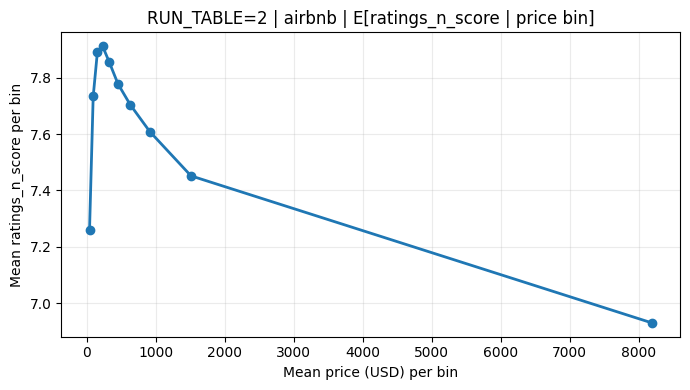

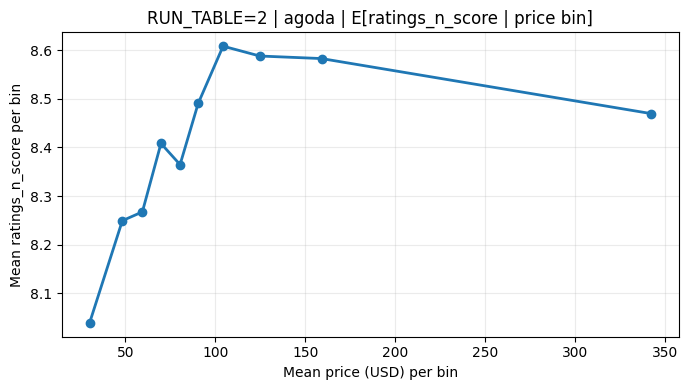

In [0]:
# Cell 7  reg subcell_4  outputs

print(f"\n================ RUN_TABLE={RUN_TABLE} ================\n")

# 1) Parameters tables
for model_key, out in out_bundle_rt.items():
    if out is None or out.get("params_df") is None:
        print(f"[SKIP] {model_key} (no params_df)")
        continue

    print_one_model_wide(
        f"RT{RUN_TABLE}::{model_key}",
        out,
    )

# 2) Optional price effect plots
target = label if "label" in globals() else "ratings_n_score"

if all(c in unified_df.columns for c in ["source", target, "price_usd"]):

    for src in ["airbnb", "agoda"]:

        df_src = unified_df.where(F.col("source") == src)
        if df_src.count() == 0:
            continue

        df_pos_price = df_src.where(F.col("price_usd").isNotNull() & (F.col("price_usd") > 0))
        if df_pos_price.count() == 0:
            continue

        pd_price = compute_marginal_by_price_bins(
            unified_df,
            source_value=src,
            target_col=target,
            price_col="price_usd",
            n_bins=10,
        )

        if pd_price is not None and not pd_price.empty:
            plot_marginal_price_effect(
                pd_price,
                source_value=src,
                target_col=target,
                title=f"RUN_TABLE={RUN_TABLE} | {src} | E[{target} | price bin]",
            )

# Neural Network

### Cell 8  Choose features  
### Define target and numeric feature list for current case

In [0]:
# Cell 8
# ============================================================
# Step 0 — Feature selection based on RUN_TABLE
# ============================================================
# Why this cell:
# - Allows experimentation with different feature sets via RUN_TABLE switch
# - RUN_TABLE=1: Full feature set (all numeric features)
# - RUN_TABLE=2: Reduced feature set (drop user based features)
# - RUN_TABLE=3-5: Source-specific experiments 
#
# Target: ratings (raw rating score [1,10])
# Features: Numeric features only (categorical handled via embeddings in Step 1)

TARGET_COL = label

# Use all numeric features except the target and categorical columns
NUM_COLS = [
    f.name for f in unified_df.schema.fields
    if f.name not in {"source", "id", "name", "city", TARGET_COL, "booking_manager_language_spoken"}
    and f.dataType.simpleString() != "string"
]

print(f"RUN_TABLE={RUN_TABLE}: Using all numeric features ({len(NUM_COLS)} features)")
print(f"Target: {TARGET_COL}")
print(f"Features: {NUM_COLS}")

RUN_TABLE=2: Using all numeric features (13 features)
Target: ratings_n_score
Features: ['price', 'kitchen', 'wifi', 'aircon', 'parking', 'washer', 'microwave', 'fridge', 'heating', 'tv', 'pool', 'gym', 'price_usd']


In [0]:
# ============================================================
# Step 1 (robust) — Create x_num + hashed categorical IDs + export Parquet
# ============================================================
# Why this cell:
# - StringIndexer for high-cardinality columns (city) can be brittle / slow and can fail to produce output columns.
# - Hashing (xxhash64) is deterministic, scalable, and doesn't need a fit step.
# - We keep source_id as an explicit mapping (no collisions, only 3 categories).
# - Exports preprocessed data to Parquet for efficient streaming in PyTorch.
#
# Output schema per row:
#   y: float (target)
#   x_num: array<float> (length = len(NUM_COLS), in the same order)
#   source_id: int (0=airbnb, 1=booking, 2=agoda, 3=other)
#   city_id: int (hashed bucket id)

# Hash bucket size for city embeddings (tradeoff: larger = fewer collisions, more params)
CITY_BUCKETS = 200_000   # good starting point for millions of rows

def prep_hash(split_df):
    out = split_df

    # target
    out = out.withColumn("y", F.col(TARGET_COL).cast("float"))

    # numeric array (stable order, explicit cast)
    out = out.withColumn("x_num", F.array(*[F.col(c).cast("float") for c in NUM_COLS]))

    # source_id: explicit mapping (0..2)
    out = out.withColumn(
        "source_id",
        F.when(F.col("source") == F.lit("airbnb"), F.lit(0))
         .when(F.col("source") == F.lit("booking"), F.lit(1))
         .when(F.col("source") == F.lit("agoda"), F.lit(2))
         .otherwise(F.lit(3))  # safety bucket
         .cast("int")
    )

    # city_id: hashing trick (0..CITY_BUCKETS-1), handle null city
    out = out.withColumn(
        "city_id",
        F.pmod(F.abs(F.xxhash64(F.coalesce(F.col("city"), F.lit("")))), F.lit(CITY_BUCKETS)).cast("int")
    )

    return out.select("y", "x_num", "source_id", "city_id")

# Split train_df into train_df and val_df (95%/5%)
TRAIN_SPLIT = 0.95
VAL_SPLIT = 0.05
train_df_split, val_df = train_df.randomSplit([TRAIN_SPLIT, VAL_SPLIT], seed=42)

# Make sure we only drop rows missing the target (features handled by preprocessing)
train_out = prep_hash(train_df_split.dropna(subset=[TARGET_COL]))
val_out   = prep_hash(val_df.dropna(subset=[TARGET_COL]))
test_out  = prep_hash(test_df.dropna(subset=[TARGET_COL]))

BASE_PATH = f"dbfs:/tmp/ratings_dnn_cpu_run{RUN_TABLE}"

train_out.repartition(200).write.mode("overwrite").parquet(f"{BASE_PATH}/train")
val_out.repartition(50).write.mode("overwrite").parquet(f"{BASE_PATH}/val")
test_out.repartition(50).write.mode("overwrite").parquet(f"{BASE_PATH}/test")

print("✅ Saved Parquet splits to:", BASE_PATH)
print("NUM features:", len(NUM_COLS))
print("CITY_BUCKETS:", CITY_BUCKETS)
train_out.printSchema()

# Verify that files were successfully written
def _dbfs_to_local(path: str) -> str:
    return "/dbfs/" + path[len("dbfs:/"):] if path.startswith("dbfs:/") else path

local_base = _dbfs_to_local(BASE_PATH)
print("\n🔍 Verifying Parquet files...")

for split_name in ["train", "val", "test"]:
    split_path = os.path.join(local_base, split_name)
    if os.path.exists(split_path):
        parquet_files = [f for f in os.listdir(split_path) if f.endswith('.parquet')]
        if parquet_files:
            print(f"  ✅ {split_name}: {len(parquet_files)} parquet file(s)")
        else:
            print(f"  ⚠️  {split_name}: directory exists but no .parquet files found")
    else:
        print(f"  ❌ {split_name}: directory does NOT exist at {split_path}")
        raise FileNotFoundError(f"Failed to create {split_name} split at {split_path}")

print("\n✅ All Parquet files verified successfully!")

✅ Saved Parquet splits to: dbfs:/tmp/ratings_dnn_cpu_run2
NUM features: 13
CITY_BUCKETS: 200000
root
 |-- y: float (nullable = true)
 |-- x_num: array (nullable = false)
 |    |-- element: float (containsNull = false)
 |-- source_id: integer (nullable = false)
 |-- city_id: integer (nullable = true)


🔍 Verifying Parquet files...
  ✅ train: 200 parquet file(s)
  ✅ val: 50 parquet file(s)
  ✅ test: 50 parquet file(s)

✅ All Parquet files verified successfully!


### Cell 9  MLP training  
### Stream Parquet data train embedding based MLP with Huber loss and save model

In [0]:
# Cell 9
# ============================================================
# Step 2 — PyTorch streaming DataLoader + Model 1 (MLP) training (CPU)
# ============================================================
# Why this cell:
# - Streams Parquet shards from DBFS without collecting to the driver (critical for 5M+ rows).
# - Builds a tabular MLP with embeddings for:
#       - source_id (4 categories: 0..3)
#       - city_id   (hashed buckets: 200000)
# - Trains using Huber (SmoothL1) loss:
#       - More robust than MSE when labels contain outliers/noise (common in mixed-source ratings).
# - Saves model weights to disk for later inference.
# - Early stopping on validation RMSE to prevent overfitting.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths (Spark wrote to dbfs:/..., pyarrow reads from /dbfs/...)
# ------------------------------------------------------------
BASE_PATH = f"dbfs:/tmp/ratings_dnn_cpu_run{RUN_TABLE}"

def _dbfs_to_local(path: str) -> str:
    return "/dbfs/" + path[len("dbfs:/"):] if path.startswith("dbfs:/") else path

TRAIN_DIR = _dbfs_to_local(f"{BASE_PATH}/train")
VAL_DIR   = _dbfs_to_local(f"{BASE_PATH}/val")
TEST_DIR  = _dbfs_to_local(f"{BASE_PATH}/test")

# Check that data exists before proceeding
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(
        f"Training data not found at {TRAIN_DIR}. "
        "Please run the data export cell (Step 1) first to create the Parquet files."
    )
if not os.path.exists(VAL_DIR):
    raise FileNotFoundError(
        f"Validation data not found at {VAL_DIR}. "
        "Please run the data export cell (Step 1) first to create the Parquet files."
    )

# ------------------------------------------------------------
# Streaming dataset: yields pre-batched tensors from Parquet
# ------------------------------------------------------------
class ParquetBatchDataset(IterableDataset):
    """
    Streams parquet record-batches (already batched) and yields:
        x_num: [B, n_num] float32
        source_id: [B] int64
        city_id: [B] int64
        y: [B] float32
    """
    def __init__(self, parquet_dir: str, batch_rows: int = 8192):
        super().__init__()
        self.parquet_dir = parquet_dir
        self.batch_rows = batch_rows

    def __iter__(self):
        dataset = ds.dataset(self.parquet_dir, format="parquet")
        scanner = dataset.scanner(batch_size=self.batch_rows)

        for rb in scanner.to_batches():
            cols = rb.to_pydict()

            # y: list[float] - handle None and NaN
            y_raw = cols["y"]
            y_clean = [0.0 if (v is None or (isinstance(v, float) and math.isnan(v))) else float(v) for v in y_raw]
            y = torch.tensor(y_clean, dtype=torch.float32)

            # source_id / city_id: lists[int] (city_id can be nullable)
            source_id = torch.tensor(cols["source_id"], dtype=torch.long)
            # city_id may contain None -> map None -> 0
            city_list = [0 if v is None else int(v) for v in cols["city_id"]]
            city_id = torch.tensor(city_list, dtype=torch.long)

            # x_num: list[list[float or None]]
            # elements may be None or NaN -> map to 0.0 to keep tensors numeric
            x_rows = cols["x_num"]
            x_clean = [[0.0 if (v is None or (isinstance(v, float) and math.isnan(v))) else float(v) for v in row] for row in x_rows]
            x_num = torch.tensor(x_clean, dtype=torch.float32)

            yield x_num, source_id, city_id, y

def make_loader(parquet_dir: str, batch_rows: int = 8192, num_workers: int = 0):
    dset = ParquetBatchDataset(parquet_dir, batch_rows=batch_rows)
    # Dataset already yields batches, so batch_size=None
    return DataLoader(dset, batch_size=None, num_workers=num_workers)

train_loader = make_loader(TRAIN_DIR, batch_rows=8192)
val_loader   = make_loader(VAL_DIR,   batch_rows=8192)
test_loader  = make_loader(TEST_DIR,  batch_rows=8192)

# ------------------------------------------------------------
# Model 1: Embeddings + MLP
# ------------------------------------------------------------
class TabMLP(nn.Module):
    """
    Tabular MLP with embeddings for source_id and city_id.
    Output bounded to [0, 10] via sigmoid (adjust y_max if your ratings range differs).
    """
    def __init__(self, n_num: int, city_buckets: int, source_buckets: int = 4,
                 d_source: int = 4, d_city: int = 32,
                 hidden=(256, 256, 128), dropout=0.2,
                 y_max: float = 10.0):
        super().__init__()
        self.y_max = y_max

        self.emb_source = nn.Embedding(source_buckets, d_source)
        self.emb_city   = nn.Embedding(city_buckets, d_city)

        d_in = n_num + d_source + d_city

        layers = []
        prev = d_in
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.BatchNorm1d(h),
                nn.Dropout(dropout),
            ]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x_num, source_id, city_id):
        e_source = self.emb_source(source_id)
        e_city = self.emb_city(city_id)
        x = torch.cat([x_num, e_source, e_city], dim=1)
        raw = self.net(x).squeeze(1)
        # bound predictions to [0, y_max] (helps stabilize; adjust if rating scale differs)
        pred = self.y_max * torch.sigmoid(raw)
        return pred

# Feature count from your export
N_NUM = len(NUM_COLS)
CITY_BUCKETS = 200_000
SOURCE_BUCKETS = 4  # because we used 0..3 in Spark mapping

model = TabMLP(
    n_num=N_NUM,
    city_buckets=CITY_BUCKETS,
    source_buckets=SOURCE_BUCKETS,
    d_source=4,
    d_city=32,
    hidden=(256, 256, 128),
    dropout=0.2,
    y_max=10.0
).to(DEVICE)

print(f"Model initialized with {N_NUM} numeric features")

# ------------------------------------------------------------
# Training utilities: Huber loss + early stopping on val RMSE
# ------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, max_batches=None):
    model.eval()
    ys, ps = [], []
    for i, (x_num, source_id, city_id, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x_num = x_num.to(DEVICE)
        source_id = source_id.to(DEVICE)
        city_id = city_id.to(DEVICE)

        pred = model(x_num, source_id, city_id).detach().cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)

    y_true = np.concatenate(ys) if ys else np.array([])
    y_pred = np.concatenate(ps) if ps else np.array([])

    # Check for empty or invalid data
    if len(y_true) == 0 or len(y_pred) == 0:
        raise ValueError("No data loaded from loader. Check that Parquet files contain data.")
    if np.isnan(y_true).any():
        raise ValueError(f"y_true contains {np.isnan(y_true).sum()} NaN values")
    if np.isnan(y_pred).any():
        raise ValueError(f"y_pred contains {np.isnan(y_pred).sum()} NaN values (model produced NaN)")

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4,
                huber_delta=1.0, patience=3):
    """
    Why Huber (SmoothL1) instead of MSE:
    - MSE over-penalizes large residuals. Ratings across sources can have noise/outliers.
    - Huber is quadratic near zero (like MSE) but linear for large errors (more robust).
    We still evaluate with RMSE/R² per your assignment metric.
    """
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss(beta=huber_delta)  # Huber loss

    best_val = float("inf")
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        losses = []

        for x_num, source_id, city_id, y in train_loader:
            x_num = x_num.to(DEVICE)
            source_id = source_id.to(DEVICE)
            city_id = city_id.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x_num, source_id, city_id)
            loss = loss_fn(pred, y)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            losses.append(loss.item())

        val_rmse, val_r2 = evaluate(model, val_loader, max_batches=200)  # speed-up for CPU
        print(f"Epoch {ep:02d} | train_loss={np.mean(losses):.4f} | val_RMSE={val_rmse:.4f} | val_R2={val_r2:.4f}")

        # Early stopping on RMSE
        if val_rmse < best_val - 1e-4:
            best_val = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# ------------------------------------------------------------
# Train 
# ------------------------------------------------------------
model = train_model(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,        
    lr=1e-3,
    weight_decay=1e-4,
    huber_delta=1.0,
    patience=3
)

# ------------------------------------------------------------
# Save model weights
# ------------------------------------------------------------
MODEL_PATH = f"/dbfs/tmp/ratings_dnn_cpu_run{RUN_TABLE}/model.pt"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"\n✅ Saved model weights to: {MODEL_PATH}")

Device: cpu
Model initialized with 13 numeric features
Epoch 01 | train_loss=1.3497 | val_RMSE=2.6670 | val_R2=-0.0441
Epoch 02 | train_loss=1.1321 | val_RMSE=2.6032 | val_R2=0.0052
Epoch 03 | train_loss=1.1124 | val_RMSE=2.6045 | val_R2=0.0043
Epoch 04 | train_loss=1.0923 | val_RMSE=2.6073 | val_R2=0.0021
Epoch 05 | train_loss=1.0837 | val_RMSE=2.5749 | val_R2=0.0268
Epoch 06 | train_loss=1.0659 | val_RMSE=2.5093 | val_R2=0.0757
Epoch 07 | train_loss=1.0596 | val_RMSE=2.5275 | val_R2=0.0623
Epoch 08 | train_loss=1.0452 | val_RMSE=2.4939 | val_R2=0.0871
Epoch 09 | train_loss=1.0326 | val_RMSE=2.5098 | val_R2=0.0753
Epoch 10 | train_loss=1.0254 | val_RMSE=2.4724 | val_R2=0.1027

✅ Saved model weights to: /dbfs/tmp/ratings_dnn_cpu_run2/model.pt


### Cell 10  Test evaluation  
### Load saved model run test inference compute RMSE and R² and plot calibration


TEST SET EVALUATION - RUN_TABLE=2

✅ Loaded model weights from: /dbfs/tmp/ratings_dnn_cpu_run2/model.pt


FINAL TEST METRICS
  RMSE: 2.4925 
  R²:   0.0984  



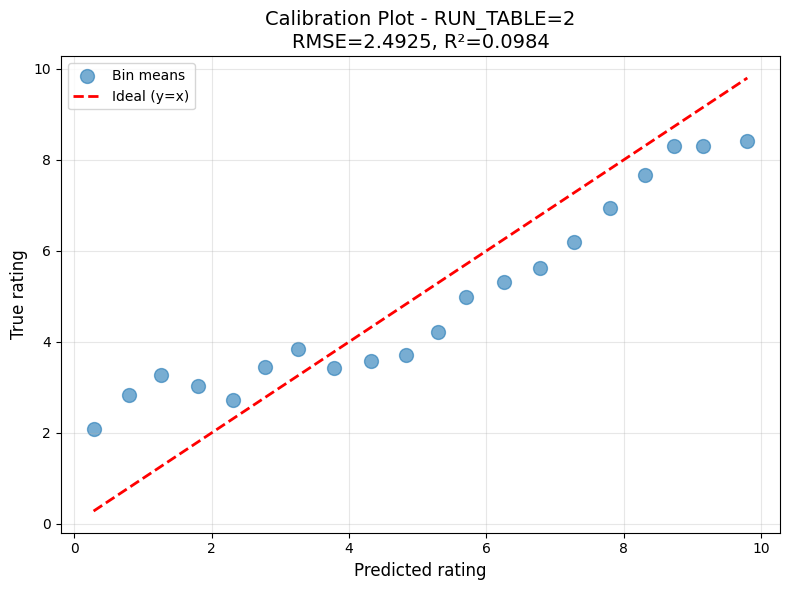


✅ Test evaluation complete for RUN_TABLE=2


In [0]:
# Cell 10
# ============================================================
# Step 3 — Load model weights, run inference on test set, display metrics
# ============================================================
# Why this cell:
# - Loads saved model weights from Step 2
# - Runs inference on the held-out test set (never seen during training)
# - Computes and displays final RMSE and R² metrics
# - Generates calibration plot to visualize prediction quality
#
# Metrics:
# - RMSE (Root Mean Squared Error): Lower is better, measures average prediction error
# - R² (R-squared): Higher is better (max 1.0), measures proportion of variance explained

print(f"\n{'='*60}")
print(f"TEST SET EVALUATION - RUN_TABLE={RUN_TABLE}")
print(f"{'='*60}\n")

# ------------------------------------------------------------
# Load model weights
# ------------------------------------------------------------
MODEL_PATH = f"/dbfs/tmp/ratings_dnn_cpu_run{RUN_TABLE}/model.pt"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model weights not found at {MODEL_PATH}. "
        "Please run Step 2 (training cell) first to train and save the model."
    )

# Recreate model architecture (must match training)
N_NUM = len(NUM_COLS)
CITY_BUCKETS = 200_000
SOURCE_BUCKETS = 4

model_test = TabMLP(
    n_num=N_NUM,
    city_buckets=CITY_BUCKETS,
    source_buckets=SOURCE_BUCKETS,
    d_source=4,
    d_city=32,
    hidden=(256, 256, 128),
    dropout=0.2,
    y_max=10.0
).to(DEVICE)

# Load saved weights
model_test.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
print(f"✅ Loaded model weights from: {MODEL_PATH}\n")

# ------------------------------------------------------------
# Run inference on test set
# ------------------------------------------------------------
test_rmse, test_r2 = evaluate(model_test, test_loader, max_batches=None)

print(f"\n{'='*60}")
print(f"FINAL TEST METRICS")
print(f"{'='*60}")
print(f"  RMSE: {test_rmse:.4f} ")
print(f"  R²:   {test_r2:.4f}  ")
print(f"{'='*60}\n")

# ------------------------------------------------------------
# Calibration plot: bin by predicted rating, compare bin means
# ------------------------------------------------------------
@torch.no_grad()
def predict_all(model, loader, max_batches=None):
    model.eval()
    ys, ps = [], []
    for i, (x_num, source_id, city_id, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x_num = x_num.to(DEVICE)
        source_id = source_id.to(DEVICE)
        city_id = city_id.to(DEVICE)
        pred = model(x_num, source_id, city_id).detach().cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

y_true, y_pred = predict_all(model_test, test_loader)

# Bin-average calibration scatter
n_bins = 20
bins = np.linspace(y_pred.min(), y_pred.max(), n_bins + 1)
bin_idx = np.digitize(y_pred, bins) - 1

bin_pred, bin_true = [], []
for b in range(n_bins):
    mask = (bin_idx == b)
    if mask.sum() == 0:
        continue
    bin_pred.append(y_pred[mask].mean())
    bin_true.append(y_true[mask].mean())

plt.figure(figsize=(8, 6))
plt.scatter(bin_pred, bin_true, s=100, alpha=0.6, label="Bin means")
mn = min(min(bin_pred), min(bin_true))
mx = max(max(bin_pred), max(bin_true))
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label="Ideal (y=x)")
plt.xlabel("Predicted rating", fontsize=12)
plt.ylabel("True rating", fontsize=12)
plt.title(f"Calibration Plot - RUN_TABLE={RUN_TABLE}\nRMSE={test_rmse:.4f}, R²={test_r2:.4f}", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Test evaluation complete for RUN_TABLE={RUN_TABLE}")

### Cell 11  Permutation importance  
### Estimate feature impact by shuffling each variable and measuring RMSE increase on test data


PERMUTATION IMPORTANCE - RUN_TABLE=2

Loading test data...
Loaded test data: 234,955 samples, 13 features

✅ Loaded model from: /dbfs/tmp/ratings_dnn_cpu_run2/model.pt


=== Computing Permutation Importance ===

Baseline RMSE: 2.4925

Permuting numeric features...
                      price -> RMSE 4.5288 | Δ +2.0363
                    kitchen -> RMSE 2.5031 | Δ +0.0106
                       wifi -> RMSE 2.5028 | Δ +0.0103
                     aircon -> RMSE 2.6274 | Δ +0.1349
                    parking -> RMSE 2.4994 | Δ +0.0069
                     washer -> RMSE 2.6193 | Δ +0.1268
                  microwave -> RMSE 2.4944 | Δ +0.0019
                     fridge -> RMSE 2.5077 | Δ +0.0153
                    heating -> RMSE 2.4904 | Δ -0.0021
                         tv -> RMSE 2.5010 | Δ +0.0085
                       pool -> RMSE 2.4981 | Δ +0.0056
                        gym -> RMSE 2.4954 | Δ +0.0029
                  price_usd -> RMSE 4.6157 | Δ +2.1233

Permuting categori

feature,delta_rmse,rmse_shuffled
price_usd,2.1232519149780273,4.615737438201904
price,2.03629207611084,4.528777599334717
source_id,0.33741331100463867,2.8298988342285156
city_id,0.1557934284210205,2.6482789516448975
aircon,0.13489675521850586,2.627382278442383
washer,0.12678265571594238,2.6192681789398193
fridge,0.015263080596923828,2.507748603820801
kitchen,0.010617494583129883,2.503103017807007
wifi,0.010314702987670898,2.502800226211548
tv,0.008545398712158203,2.501030921936035


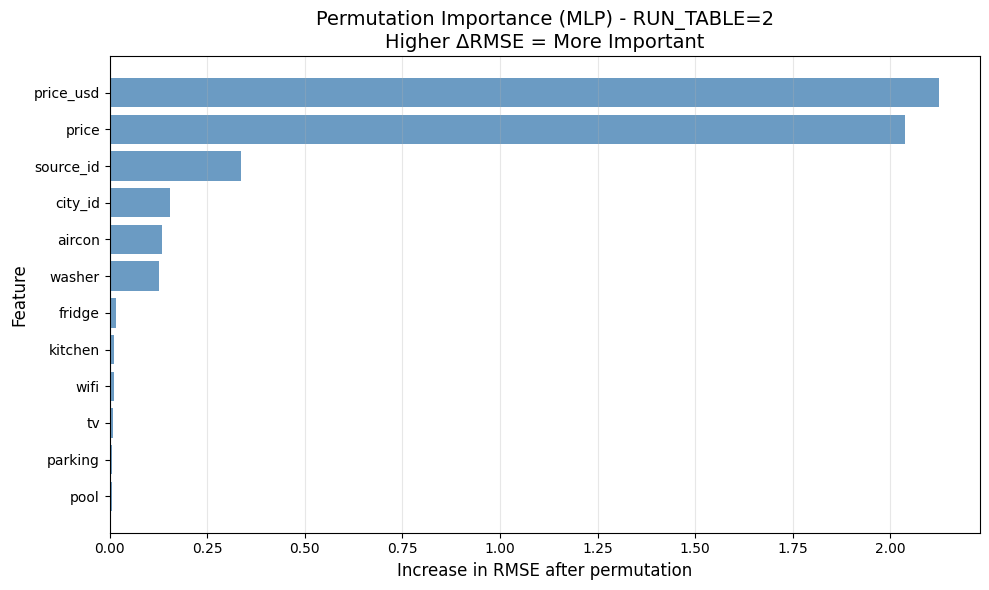


✅ Permutation importance analysis complete


In [0]:
# Cell 11
# ============================================================
# Permutation Importance for Tabular MLP (PyTorch)
# ============================================================
# Why this cell:
# - Computes permutation importance to identify which features most impact model predictions
# - Permutes each feature independently and measures increase in RMSE
# - Higher delta RMSE = more important feature
# - Uses test set data for unbiased importance estimates

print(f"\n{'='*60}")
print(f"PERMUTATION IMPORTANCE - RUN_TABLE={RUN_TABLE}")
print(f"{'='*60}\n")

# ------------------------------------------------------------
# Helper: Load all test data into numpy arrays
# ------------------------------------------------------------
def load_test_data_to_numpy(loader):
    """
    Collect all batches from test_loader into numpy arrays.
    Returns: X_num_np, source_np, city_np, y_np
    """
    X_batches, source_batches, city_batches, y_batches = [], [], [], []
    
    for x_num, source_id, city_id, y in loader:
        X_batches.append(x_num.numpy())
        source_batches.append(source_id.numpy())
        city_batches.append(city_id.numpy())
        y_batches.append(y.numpy())
    
    X_num_np = np.concatenate(X_batches, axis=0)
    source_np = np.concatenate(source_batches, axis=0)
    city_np = np.concatenate(city_batches, axis=0)
    y_np = np.concatenate(y_batches, axis=0)
    
    print(f"Loaded test data: {X_num_np.shape[0]:,} samples, {X_num_np.shape[1]} features")
    return X_num_np, source_np, city_np, y_np

print("Loading test data...")
X_num_np, source_np, city_np, y_np = load_test_data_to_numpy(test_loader)

# ------------------------------------------------------------
# Permutation importance functions
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def predict_numpy(tab_model, X_num, source_id, city_id, batch_size=8192):
    """
    Batched prediction for tabular MLP.
    Inputs:
      - tab_model: trained PyTorch model (on .eval())
      - X_num: np.ndarray [N, d]
      - source_id: np.ndarray [N]
      - city_id: np.ndarray [N]
    Returns:
      - y_pred: np.ndarray [N]
    """
    tab_model.eval()
    y_pred = []
    N = X_num.shape[0]
    for i in range(0, N, batch_size):
        xb = torch.tensor(X_num[i:i+batch_size], dtype=torch.float32, device=DEVICE)
        sb = torch.tensor(source_id[i:i+batch_size], dtype=torch.long, device=DEVICE)
        cb = torch.tensor(city_id[i:i+batch_size], dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            pb = tab_model(xb, sb, cb).cpu().numpy()
        y_pred.append(pb)
    return np.concatenate(y_pred)

ALL_FEATURES = NUM_COLS + ["source_id", "city_id"]

def permutation_importance(tab_model, X_num, source_id, city_id, y_true, seed=0, batch_size=8192):
    """
    Compute permutation importance for all features.
    Returns: (baseline_rmse, importance_dataframe)
    """
    rng = np.random.default_rng(seed)
    base_pred = predict_numpy(tab_model, X_num, source_id, city_id, batch_size=batch_size)
    base_rmse = rmse(y_true, base_pred)
    results = []
    print(f"Baseline RMSE: {base_rmse:.4f}\n")

    # Numeric features
    print("Permuting numeric features...")
    for j, fname in enumerate(NUM_COLS):
        Xp = X_num.copy()
        perm = rng.permutation(Xp.shape[0])
        Xp[:, j] = Xp[perm, j]
        pred = predict_numpy(tab_model, Xp, source_id, city_id, batch_size=batch_size)
        r = rmse(y_true, pred)
        results.append((fname, r - base_rmse, r))
        print(f"  {fname:>25s} -> RMSE {r:.4f} | Δ {r-base_rmse:+.4f}")

    # source_id
    print("\nPermuting categorical features...")
    perm = rng.permutation(source_id.shape[0])
    sp = source_id[perm]
    pred = predict_numpy(tab_model, X_num, sp, city_id, batch_size=batch_size)
    r = rmse(y_true, pred)
    results.append(("source_id", r - base_rmse, r))
    print(f"  {'source_id':>25s} -> RMSE {r:.4f} | Δ {r-base_rmse:+.4f}")

    # city_id
    perm = rng.permutation(city_id.shape[0])
    cp = city_id[perm]
    pred = predict_numpy(tab_model, X_num, source_id, cp, batch_size=batch_size)
    r = rmse(y_true, pred)
    results.append(("city_id", r - base_rmse, r))
    print(f"  {'city_id':>25s} -> RMSE {r:.4f} | Δ {r-base_rmse:+.4f}")

    df = pd.DataFrame(results, columns=["feature", "delta_rmse", "rmse_shuffled"])
    df = df.sort_values("delta_rmse", ascending=False).reset_index(drop=True)
    return base_rmse, df

# ------------------------------------------------------------
# Load trained model and compute importance
# ------------------------------------------------------------
MODEL_PATH = f"/dbfs/tmp/ratings_dnn_cpu_run{RUN_TABLE}/model.pt"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model weights not found at {MODEL_PATH}. "
        "Please run Step 2 (training cell) first."
    )

# Recreate model architecture
N_NUM = len(NUM_COLS)
CITY_BUCKETS = 200_000
SOURCE_BUCKETS = 4

model_perm = TabMLP(
    n_num=N_NUM,
    city_buckets=CITY_BUCKETS,
    source_buckets=SOURCE_BUCKETS,
    d_source=4,
    d_city=32,
    hidden=(256, 256, 128),
    dropout=0.2,
    y_max=10.0
).to(DEVICE)

model_perm.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
print(f"\n✅ Loaded model from: {MODEL_PATH}\n")

# Compute permutation importance
print("\n=== Computing Permutation Importance ===\n")
mlp_base_rmse, mlp_imp = permutation_importance(
    model_perm, X_num_np, source_np, city_np, y_np, seed=42
)

print(f"\n{'='*60}")
print(f"TOP 12 MOST IMPORTANT FEATURES")
print(f"{'='*60}")
display(mlp_imp.head(12))

# ------------------------------------------------------------
# Visualization: Top features by importance
# ------------------------------------------------------------
topk = min(12, len(mlp_imp))
plt.figure(figsize=(10, 6))
plt.barh(
    mlp_imp["feature"].head(topk)[::-1], 
    mlp_imp["delta_rmse"].head(topk)[::-1], 
    color='steelblue',
    alpha=0.8
)
plt.xlabel("Increase in RMSE after permutation", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title(f"Permutation Importance (MLP) - RUN_TABLE={RUN_TABLE}\nHigher ΔRMSE = More Important", fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Permutation importance analysis complete")

# Classification models

### Cell 12  Rating distribution  
### Clean label bucket scores and compare full train and test splits

In [0]:

# Cell 12
LABEL_SRC = "ratings_n_score"

# ------------------------------------------------
# 0) IMPORTANT: unified_df is ALREADY filtered by RUN_TABLE=2
#    and already had ratings + n_reviews dropped in your Cell 3.
#    train_df / test_df already exist (95/5 split).
# ------------------------------------------------

def label_clean_and_bucket(df, label_col=LABEL_SRC):
    """
    - Convert -1 to NULL
    - Keep only non-null label
    - Create bucket column:
        1–8, 8–9, 9–10, out_of_range
    Returns: (df_clean, total_rows, dist_df, out_of_range_cnt)
    """
    df0 = (
        df
        .withColumn(label_col, F.when(F.col(label_col) == -1, None).otherwise(F.col(label_col)).cast("double"))
        .filter(F.col(label_col).isNotNull())
        .cache()
    )

    total_rows = df0.count()

    bucketed = df0.withColumn(
        "rating_bucket",
        F.when((F.col(label_col) >= 1.0) & (F.col(label_col) < 8.0), "1–8")
         .when((F.col(label_col) >= 8.0) & (F.col(label_col) < 9.0), "8–9")
         .when((F.col(label_col) >= 9.0) & (F.col(label_col) <= 10.0), "9–10")
         .otherwise("out_of_range")
    )

    dist = (
        bucketed
        .groupBy("rating_bucket")
        .count()
        .withColumn("percent", F.round(F.col("count") / F.lit(total_rows) * 100, 2))
        .orderBy("rating_bucket")
    )

    out_of_range_cnt = bucketed.filter(F.col("rating_bucket") == "out_of_range").count()

    return df0, total_rows, dist, out_of_range_cnt


# ------------------------------------------------
# A) Full dataset distribution (AFTER RUN_TABLE=2 filtering)
# ------------------------------------------------
df0_all, total_all, dist_all, oor_all = label_clean_and_bucket(unified_df)

print("=== FULL DATASET (after RUN_TABLE filtering) ===")
print("Total rows with valid label:", total_all)

df0_all.select(
    F.min(LABEL_SRC).alias("min_rating"),
    F.expr(f"percentile_approx({LABEL_SRC}, 0.05)").alias("p05"),
    F.expr(f"percentile_approx({LABEL_SRC}, 0.25)").alias("p25"),
    F.expr(f"percentile_approx({LABEL_SRC}, 0.50)").alias("median"),
    F.expr(f"percentile_approx({LABEL_SRC}, 0.75)").alias("p75"),
    F.expr(f"percentile_approx({LABEL_SRC}, 0.95)").alias("p95"),
    F.max(LABEL_SRC).alias("max_rating"),
    F.avg(LABEL_SRC).alias("mean_rating")
).show(truncate=False)

print("Bucket distribution (FULL):")
dist_all.show(truncate=False)

print("Out-of-range rows (FULL):", oor_all)


# ------------------------------------------------
# B) Train/Test distributions (same bucketing)
# ------------------------------------------------
df0_tr, total_tr, dist_tr, oor_tr = label_clean_and_bucket(train_df)
df0_te, total_te, dist_te, oor_te = label_clean_and_bucket(test_df)

print("\n=== TRAIN SET ===")
print("Train rows with valid label:", total_tr)
print("Bucket distribution (TRAIN):")
dist_tr.show(truncate=False)
print("Out-of-range rows (TRAIN):", oor_tr)

print("\n=== TEST SET ===")
print("Test rows with valid label:", total_te)
print("Bucket distribution (TEST):")
dist_te.show(truncate=False)
print("Out-of-range rows (TEST):", oor_te)


=== FULL DATASET (after RUN_TABLE filtering) ===
Total rows with valid label: 4682465
+----------+---+-----------------+------+-----------------+-----+----------+-----------------+
|min_rating|p05|p25              |median|p75              |p95  |max_rating|mean_rating      |
+----------+---+-----------------+------+-----------------+-----+----------+-----------------+
|0.5       |0.5|7.174999999999999|8.75  |9.531999999722583|9.928|10.0      |7.727608738148349|
+----------+---+-----------------+------+-----------------+-----+----------+-----------------+

Bucket distribution (FULL):
+-------------+-------+-------+
|rating_bucket|count  |percent|
+-------------+-------+-------+
|1–8          |1275012|27.23  |
|8–9          |1012005|21.61  |
|9–10         |2051185|43.81  |
|out_of_range |344263 |7.35   |
+-------------+-------+-------+

Out-of-range rows (FULL): 344263

=== TRAIN SET ===
Train rows with valid label: 4447510
Bucket distribution (TRAIN):
+-------------+-------+-------+
|ra

### Cell 13  Fast classification baseline  
### Build 3 class label sample train split train Random Forest and evaluate on full test set

In [0]:
# Cel 13

SEED = 42
TRAIN_SAMPLE_FRAC = 0.3   # sample ONLY the train split for fast experiments
LABEL_SRC = "ratings_n_score"

# Evaluators
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

def minus1_to_null(df, cols):
    """Convert sentinel -1 to NULL for numeric columns."""
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

def add_3class_label(df):
    """
    - Convert label -1 -> NULL
    - Keep label in [1,10]
    - Create 3-class label:
        0: [1,8)
        1: [8,9)
        2: [9,10]
    """
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            "label",
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col("label").isNotNull())
    )

def run_fast_baseline_on_split(train_df, test_df, name):
    """
    Train on (sampled) train_df and evaluate on full test_df.
    Assumes train_df/test_df were created by your RUN_TABLE cell (95/5 split).
    """
    print("\n==============================")
    print(f"Running baseline for {name}")
    print("==============================")

    # 1) Add label bins on BOTH train & test (and filter out-of-range)
    train_l = add_3class_label(train_df)
    test_l  = add_3class_label(test_df)

    train_l = train_l.persist(StorageLevel.MEMORY_AND_DISK)
    test_l  = test_l.persist(StorageLevel.MEMORY_AND_DISK)

    n_train_full = train_l.count()
    n_test_full  = test_l.count()
    print(f"Train rows (valid label): {n_train_full:,} | Test rows (valid label): {n_test_full:,}")

    print("Label distribution (train):")
    train_l.groupBy("label").count().orderBy("label").show()

    print("Label distribution (test):")
    test_l.groupBy("label").count().orderBy("label").show()

    # 2) Feature selection: drop obvious strings/ids
    DROP_ALWAYS = {"id", "name", "city", "currency", "source", "booking_manager_language_spoken", "label", LABEL_SRC}
    dtype_map = dict(train_l.dtypes)

    feature_candidates = [c for c in train_l.columns if c not in DROP_ALWAYS and str(c).strip() != ""]
    num_cols = [c for c in feature_candidates if dtype_map.get(c) != "string"]
    print("Number of features:", len(num_cols))

    # 3) Cast booleans to int (both train and test)
    bool_cols = [c for c, t in train_l.dtypes if t == "boolean" and c in num_cols]
    for c in bool_cols:
        train_l = train_l.withColumn(c, F.col(c).cast("int"))
        test_l  = test_l.withColumn(c, F.col(c).cast("int"))

    # 4) Sample TRAIN only for speed
    train_small = train_l.sample(False, TRAIN_SAMPLE_FRAC, SEED).persist(StorageLevel.MEMORY_AND_DISK)
    n_train_small = train_small.count()
    print(f"Train sampled rows: {n_train_small:,} ({TRAIN_SAMPLE_FRAC*100:.1f}%)")

    # Majority baseline from train sample
    dist = (
        train_small.groupBy("label").count()
        .withColumn("pct", F.round(F.col("count") / F.lit(n_train_small) * 100, 2))
        .orderBy("label")
    )
    dist.show()
    majority_pct = dist.agg(F.max("pct")).collect()[0][0]
    print(f"Majority-class baseline accuracy ≈ {majority_pct}%")

    # 5) Missing handling + Imputer (fit on train_small, transform train_small + test_l)
    train0 = minus1_to_null(train_small, num_cols)
    test0  = minus1_to_null(test_l,      num_cols)

    imputer = Imputer(inputCols=num_cols, outputCols=[f"{c}__imp" for c in num_cols]).setStrategy("median")
    imp_cols = [f"{c}__imp" for c in num_cols]

    assembler = VectorAssembler(inputCols=imp_cols, outputCol="features", handleInvalid="keep")

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=60,      # keep fast
        maxDepth=7,
        featureSubsetStrategy="sqrt",
        seed=SEED
    )

    pipeline = Pipeline(stages=[imputer, assembler, rf])

    # 6) Train on sampled train, evaluate on full test
    model = pipeline.fit(train0)

    pred = model.transform(test0).persist(StorageLevel.MEMORY_AND_DISK)
    _ = pred.count()

    f1 = eval_f1.evaluate(pred)
    acc = eval_acc.evaluate(pred)
    print(f"{name} | F1 = {f1:.4f} | Accuracy = {acc:.4f}")

    print("Confusion matrix (on TEST):")
    display(
        pred.groupBy(
            F.col("label").cast("int").alias("label"),
            F.col("prediction").cast("int").alias("pred")
        ).count().orderBy("label", "pred")
    )

    return {
        "name": name,
        "features": len(num_cols),
        "train_rows_full": n_train_full,
        "train_rows_sampled": n_train_small,
        "test_rows": n_test_full,
        "f1": f1,
        "acc": acc
    }


### Cell 14  Drop unused source columns  
### Remove source specific features after RUN_TABLE filtering to avoid empty columns

In [0]:
# Cell 14

# ------------------------------------------------
# Universal patch: drop source-specific columns
# after RUN_TABLE filtering to avoid all-NULL features
# ------------------------------------------------
if RUN_TABLE in [3, 4, 5]:
    if RUN_TABLE == 3:      # Airbnb filtered out
        prefix = "airbnb_"
    elif RUN_TABLE == 4:    # Booking filtered out
        prefix = "booking_"
    elif RUN_TABLE == 5:    # Agoda filtered out
        prefix = "agoda_"

    drop_cols = [c for c in unified_df.columns if c.startswith(prefix)]

    if drop_cols:
        print(f"Dropping {prefix[:-1]}-specific columns for RUN_TABLE={RUN_TABLE}:")
        print(drop_cols)
        unified_df = unified_df.drop(*drop_cols)


### Cell 15  Drop unused source columns  
### Remove source specific features from train and test after RUN_TABLE filtering

In [0]:
# Cell 15
if RUN_TABLE in [3, 4, 5]:
    prefix = "airbnb_" if RUN_TABLE == 3 else ("booking_" if RUN_TABLE == 4 else "agoda_")
    drop_cols = [c for c in train_df.columns if c.startswith(prefix)]
    if drop_cols:
        print(f"Dropping {prefix[:-1]}-specific columns from train/test:", drop_cols)
        train_df = train_df.drop(*drop_cols)
        test_df  = test_df.drop(*drop_cols)

### Cell 16  Run baseline experiment  
### Train Random Forest baseline on sampled train and evaluate on test

In [0]:
# Cell 16
res = run_fast_baseline_on_split(train_df, test_df, "RUN_TABLE=2 baseline RF")



Running baseline for RUN_TABLE=2 baseline RF
Train rows (valid label): 4,120,683 | Test rows (valid label): 217,519
Label distribution (train):
+-----+-------+
|label|  count|
+-----+-------+
|  0.0|1210855|
|  1.0| 961490|
|  2.0|1948338|
+-----+-------+

Label distribution (test):
+-----+------+
|label| count|
+-----+------+
|  0.0| 64157|
|  1.0| 50515|
|  2.0|102847|
+-----+------+

Number of features: 13
Train sampled rows: 1,236,353 (30.0%)
+-----+------+-----+
|label| count|  pct|
+-----+------+-----+
|  0.0|363041|29.36|
|  1.0|289242|23.39|
|  2.0|584070|47.24|
+-----+------+-----+

Majority-class baseline accuracy ≈ 47.24%


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run intrigued-sloth-263 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/8623f3eea7544a0f911436dada605108
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
RUN_TABLE=2 baseline RF | F1 = 0.5067 | Accuracy = 0.5540
Confusion matrix (on TEST):


label,pred,count
0,0,13036
0,1,9887
0,2,41234
1,0,1309
1,1,17351
1,2,31855
2,0,3544
2,1,9180
2,2,90123


### Cell 17  Strong RF baseline with feature importance  
### Train deeper Random Forest evaluate on full test and inspect top important features

In [0]:
# Cell 17
# ============================================================
# RUN_TABLE=2 setup (already done upstream) + 95/5 split
# Fast RF + Feature Importance
# Trains on (sampled) TRAIN, evaluates on FULL TEST
# ============================================================
# -----------------------------
# Config
# -----------------------------
SEED = 42
LABEL_SRC = "ratings_n_score"

TRAIN_SAMPLE_FRAC = 1.0   # <<< set 0.1 / 0.3 for speed, 1.0 = full train
RF_NUM_TREES = 200        # stronger than 60, still reasonable
RF_MAX_DEPTH = 10
TOP_N = 20

# -----------------------------
# Evaluators
# -----------------------------
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# -----------------------------
# Helpers
# -----------------------------
def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

def add_3class_label(df):
    """
    - Convert label -1 -> NULL
    - Filter label in [1,10]
    - Create 3-class label:
        0: [1,8)
        1: [8,9)
        2: [9,10]
    """
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            "label",
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col("label").isNotNull())
    )

def select_numeric_features(df):
    """
    Keep numeric/binary features only (skip strings).
    Also drop IDs / obvious non-features.
    """
    DROP_ALWAYS = {
        "id", "name", "city", "currency", "source",
        "booking_manager_language_spoken",
        "label", LABEL_SRC
    }

    dtype_map = dict(df.dtypes)
    candidates = [c for c in df.columns if c not in DROP_ALWAYS and str(c).strip() != ""]
    num_cols = [c for c in candidates if dtype_map.get(c) != "string"]
    return num_cols

def cast_booleans_to_int(df, cols):
    for c, t in df.dtypes:
        if t == "boolean" and c in cols:
            df = df.withColumn(c, F.col(c).cast("int"))
    return df

# -----------------------------
# Main run
# -----------------------------
print("Preparing labeled train/test...")

train_l = add_3class_label(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_l  = add_3class_label(test_df ).persist(StorageLevel.MEMORY_AND_DISK)

n_train = train_l.count()
n_test  = test_l.count()
print(f"Train rows (valid label): {n_train:,} | Test rows (valid label): {n_test:,}")

print("Label distribution (train):")
train_l.groupBy("label").count().orderBy("label").show()

print("Label distribution (test):")
test_l.groupBy("label").count().orderBy("label").show()

# Feature list from TRAIN schema
num_cols = select_numeric_features(train_l)
print("Number of features:", len(num_cols))

# Cast booleans to int on both
train_l = cast_booleans_to_int(train_l, num_cols)
test_l  = cast_booleans_to_int(test_l,  num_cols)

# Sample TRAIN only (optional)
if TRAIN_SAMPLE_FRAC < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

n_train_use = train_use.count()
print(f"Train used rows: {n_train_use:,} (sample_frac={TRAIN_SAMPLE_FRAC})")

# Missing handling (-1 -> NULL) + Impute median
train0 = minus1_to_null(train_use, num_cols)
test0  = minus1_to_null(test_l,   num_cols)

imputer = Imputer(inputCols=num_cols, outputCols=[f"{c}__imp" for c in num_cols]).setStrategy("median")
imp_cols = [f"{c}__imp" for c in num_cols]

assembler = VectorAssembler(inputCols=imp_cols, outputCol="features", handleInvalid="keep")

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=RF_NUM_TREES,
    maxDepth=RF_MAX_DEPTH,
    featureSubsetStrategy="sqrt",
    seed=SEED
)

pipeline = Pipeline(stages=[imputer, assembler, rf])

print("Training RF...")
model = pipeline.fit(train0)

print("Evaluating on FULL test...")
pred = model.transform(test0).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred.count()

f1 = eval_f1.evaluate(pred)
acc = eval_acc.evaluate(pred)

print(f"RF | F1={f1:.4f} | Acc={acc:.4f}")

print("Confusion matrix (TEST):")
display(
    pred.groupBy(
        F.col("label").cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)

# Extract feature importances from trained RF model
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()
imp_sorted = sorted(zip(num_cols, importances), key=lambda x: x[1], reverse=True)

print(f"\nTop-{TOP_N} feature importances:")
for f, s in imp_sorted[:TOP_N]:
    print(f"{f}: {float(s):.6f}")

top5_share = sum(s for _, s in imp_sorted[:5]) / (sum(s for _, s in imp_sorted) + 1e-12)
print(f"Top-5 importance share: {top5_share:.3f}")


Preparing labeled train/test...
Train rows (valid label): 4,120,683 | Test rows (valid label): 217,519
Label distribution (train):
+-----+-------+
|label|  count|
+-----+-------+
|  0.0|1210855|
|  1.0| 961490|
|  2.0|1948338|
+-----+-------+

Label distribution (test):
+-----+------+
|label| count|
+-----+------+
|  0.0| 64157|
|  1.0| 50515|
|  2.0|102847|
+-----+------+

Number of features: 13
Train used rows: 4,120,683 (sample_frac=1.0)
Training RF...


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run upbeat-rook-993 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/d0fa05f6934d4e91af6f3a87b784b0b8
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
Evaluating on FULL test...
RF | F1=0.5335 | Acc=0.5643
Confusion matrix (TEST):


label,pred,count
0,0,18867
0,1,8369
0,2,36921
1,0,4835
1,1,17719
1,2,27961
2,0,7708
2,1,8988
2,2,86151



Top-20 feature importances:
washer: 0.187703
aircon: 0.179791
kitchen: 0.168192
fridge: 0.077755
price: 0.069014
price_usd: 0.067493
pool: 0.054484
heating: 0.043017
tv: 0.038966
gym: 0.034474
wifi: 0.033967
parking: 0.023820
microwave: 0.021323
Top-5 importance share: 0.682


### Cell 18  RF with top 5 features  
### Train Random Forest using selected top features and compare performance

In [0]:
# Cell 18


SEED = 42
LABEL_SRC = "ratings_n_score"

# Top-5 (from your V2 importance run)
TOP5 = ["washer", "aircon", "kitchen", "fridge", "price_usd"]

# Control speed: sample only TRAIN (set 1.0 for full train)
TRAIN_SAMPLE_FRAC = 1.0  # e.g., 0.10 / 0.30 / 1.0

# -----------------------------
# Evaluators
# -----------------------------
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# -----------------------------
# Helper: add 3-class label (and clean label)
# -----------------------------
def add_3class_label(df):
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            "label",
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col("label").isNotNull())
    )

# -----------------------------
# Helper: convert -1 to NULL for feature columns
# -----------------------------
def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

# -----------------------------
# 1) Label both train/test (based on your existing split)
# -----------------------------
train_l = add_3class_label(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_l  = add_3class_label(test_df ).persist(StorageLevel.MEMORY_AND_DISK)

print("Train rows (valid label):", train_l.count())
print("Test rows  (valid label):", test_l.count())

# -----------------------------
# 2) Keep only TOP5 that exist
# -----------------------------
TOP5 = [c for c in TOP5 if c in train_l.columns]
print("Using TOP5:", TOP5)

# Cast booleans -> int for TOP5 (if needed)
for c, t in train_l.dtypes:
    if t == "boolean" and c in TOP5:
        train_l = train_l.withColumn(c, F.col(c).cast("int"))
        test_l  = test_l.withColumn(c, F.col(c).cast("int"))

# Treat -1 as missing for TOP5
train_l = minus1_to_null(train_l, TOP5)
test_l  = minus1_to_null(test_l,  TOP5)

# Optional: sample TRAIN only (speed)
if TRAIN_SAMPLE_FRAC < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

print(f"Train used rows: {train_use.count()} (sample_frac={TRAIN_SAMPLE_FRAC})")

# -----------------------------
# 3) Pipeline: impute + assemble + RF
# -----------------------------
imputer = Imputer(
    inputCols=TOP5,
    outputCols=[f"{c}__imp" for c in TOP5]
).setStrategy("median")

imp_cols = [f"{c}__imp" for c in TOP5]

assembler = VectorAssembler(
    inputCols=imp_cols,
    outputCol="features",
    handleInvalid="keep"
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    maxDepth=10,
    featureSubsetStrategy="auto",
    seed=SEED
)

pipeline = Pipeline(stages=[imputer, assembler, rf])

# -----------------------------
# 4) Train + evaluate on FULL test
# -----------------------------
model = pipeline.fit(train_use)

pred = model.transform(test_l).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred.count()

f1 = eval_f1.evaluate(pred)
acc = eval_acc.evaluate(pred)

print(f"RF TOP5 | F1={f1:.4f} | Acc={acc:.4f}")

print("Confusion matrix (TEST):")
display(
    pred.groupBy(
        F.col("label").cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)

# -----------------------------
# 5) Feature importance (TOP5)
# -----------------------------
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()
imp_sorted = sorted(zip(TOP5, importances), key=lambda x: x[1], reverse=True)

print("\nFeature importance (RF TOP5):")
for f, s in imp_sorted:
    print(f"{f}: {float(s):.6f}")


Train rows (valid label): 4120683
Test rows  (valid label): 217519
Using TOP5: ['washer', 'aircon', 'kitchen', 'fridge', 'price_usd']
Train used rows: 4120683 (sample_frac=1.0)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run thundering-sheep-302 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/2d1b9f5d592345a190472287ef07bd80
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
RF TOP5 | F1=0.4769 | Acc=0.5352
Confusion matrix (TEST):


label,pred,count
0,0,11352
0,1,7959
0,2,44846
1,0,739
1,1,13501
1,2,36275
2,0,3022
2,1,8266
2,2,91559



Feature importance (RF TOP5):
kitchen: 0.351088
washer: 0.259042
aircon: 0.250381
price_usd: 0.095956
fridge: 0.043533


### Cell 19  Multinomial Logistic Regression  
### Train scaled multinomial LR on top features evaluate on test and inspect class coefficients

In [0]:

# Cell 19

from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import LogisticRegression

SEED = 42
LABEL_SRC = "ratings_n_score"
LABEL_COL = "label"

# Sample only TRAIN for speed (set 1.0 for full train)
TRAIN_SAMPLE_FRAC_LR = 1.0   # e.g., 0.10 / 0.30 / 1.0

# Top-5 from your V2 importance
TOP5 = ["washer", "aircon", "kitchen", "fridge", "price_usd"]

# ------------------------------------------------
# Helper: add 3-class label (and clean label)
# ------------------------------------------------
def add_3class_label(df):
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            LABEL_COL,
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col(LABEL_COL).isNotNull())
    )

def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

# ------------------------------------------------
# 1) Label both train/test (based on existing 95/5 split)
# ------------------------------------------------
train_l = add_3class_label(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_l  = add_3class_label(test_df ).persist(StorageLevel.MEMORY_AND_DISK)

print("Train rows (valid label):", train_l.count())
print("Test rows  (valid label):", test_l.count())

print("Label distribution (train):")
train_l.groupBy(LABEL_COL).count().orderBy(LABEL_COL).show()

print("Label distribution (test):")
test_l.groupBy(LABEL_COL).count().orderBy(LABEL_COL).show()

# ------------------------------------------------
# 2) Keep only TOP5 that actually exist
# ------------------------------------------------
TOP5 = [c for c in TOP5 if c in train_l.columns]
print("Using TOP5:", TOP5)

# ------------------------------------------------
# 3) Cast booleans to int (safety)
# ------------------------------------------------
for c, t in train_l.dtypes:
    if t == "boolean" and c in TOP5:
        train_l = train_l.withColumn(c, F.col(c).cast("int"))
        test_l  = test_l.withColumn(c, F.col(c).cast("int"))

# ------------------------------------------------
# 4) Treat -1 as missing for feature cols
# ------------------------------------------------
train_l = minus1_to_null(train_l, TOP5)
test_l  = minus1_to_null(test_l,  TOP5)

# ------------------------------------------------
# 5) Sample TRAIN only (optional)
# ------------------------------------------------
if TRAIN_SAMPLE_FRAC_LR < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC_LR, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

print(f"Train used rows: {train_use.count()} (sample_frac={TRAIN_SAMPLE_FRAC_LR})")

# ------------------------------------------------
# 6) Pipeline: impute -> assemble -> scale -> multinomial LR
# ------------------------------------------------
imputer = Imputer(
    inputCols=TOP5,
    outputCols=[f"{c}__imp" for c in TOP5]
).setStrategy("median")

imp_cols = [f"{c}__imp" for c in TOP5]

assembler = VectorAssembler(
    inputCols=imp_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

lr = LogisticRegression(
    labelCol=LABEL_COL,
    featuresCol="features",
    family="multinomial",
    maxIter=60,
    regParam=0.03,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[imputer, assembler, scaler, lr])

# ------------------------------------------------
# 7) Train
# ------------------------------------------------
model_lr = pipeline_lr.fit(train_use)

# ------------------------------------------------
# 8) Test + metrics (FULL TEST, not sampled)
# ------------------------------------------------
pred_lr = model_lr.transform(test_l).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred_lr.count()

eval_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")

f1_lr = eval_f1.evaluate(pred_lr)
acc_lr = eval_acc.evaluate(pred_lr)

print(f"Multinomial Logistic Regression (TOP5) | F1 = {f1_lr:.4f} | Accuracy = {acc_lr:.4f}")

print("Confusion matrix (TEST):")
display(
    pred_lr.groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)

# ------------------------------------------------
# 9) Interpretability: coefficients (per class)
# ------------------------------------------------
lr_model = model_lr.stages[-1]
coef = lr_model.coefficientMatrix.toArray()  # (numClasses, numFeatures)

feature_names = TOP5
classes = [0, 1, 2]

print("\nLogistic Regression coefficients (abs-sorted per class):")
for i, cls in enumerate(classes):
    pairs = sorted(zip(feature_names, coef[i]), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nClass {cls}:")
    for f, w in pairs:
        print(f"{f}: {float(w):+.6f}")


Train rows (valid label): 4120683
Test rows  (valid label): 217519
Label distribution (train):
+-----+-------+
|label|  count|
+-----+-------+
|  0.0|1210855|
|  1.0| 961490|
|  2.0|1948338|
+-----+-------+

Label distribution (test):
+-----+------+
|label| count|
+-----+------+
|  0.0| 64157|
|  1.0| 50515|
|  2.0|102847|
+-----+------+

Using TOP5: ['washer', 'aircon', 'kitchen', 'fridge', 'price_usd']
Train used rows: 4120683 (sample_frac=1.0)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run luminous-fowl-125 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/8dce1459758e461f97049c9338ab7ef7
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
Multinomial Logistic Regression (TOP5) | F1 = 0.3419 | Accuracy = 0.4892
Confusion matrix (TEST):


label,pred,count
0,0,4136
0,2,60021
1,0,166
1,2,50349
2,0,570
2,2,102277



Logistic Regression coefficients (abs-sorted per class):

Class 0:
kitchen: +0.434136
washer: -0.166977
aircon: -0.126255
fridge: +0.031538
price_usd: +0.019159

Class 1:
kitchen: -0.290294
fridge: -0.208413
aircon: -0.058603
washer: -0.050298
price_usd: -0.044007

Class 2:
washer: +0.217275
aircon: +0.184858
fridge: +0.176875
kitchen: -0.143842
price_usd: +0.024847


### Cell 20  Logistic Regression with top 10 features  
### Train scaled multinomial LR on top features and evaluate on full test

In [0]:
# Cell 20


SEED = 42
LABEL_SRC = "ratings_n_score"
LABEL_COL = "label"

# Sample only TRAIN for speed (set 1.0 for full train)
TRAIN_SAMPLE_FRAC_LR = 0.10   # 0.10 = 10%

# Top-10 from your RF(V2) importance
TOP10 = [
    "washer", "aircon", "kitchen", "fridge",
    "price_usd", "price",
    "heating", "pool", "tv", "wifi"
]

# ------------------------------------------------
# Helper: add 3-class label (and clean label)
# ------------------------------------------------
def add_3class_label(df):
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            LABEL_COL,
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col(LABEL_COL).isNotNull())
    )

def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

# ------------------------------------------------
# 1) Label both train/test (based on existing 95/5 split)
# ------------------------------------------------
train_l = add_3class_label(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_l  = add_3class_label(test_df ).persist(StorageLevel.MEMORY_AND_DISK)

print("Train rows (valid label):", train_l.count())
print("Test rows  (valid label):", test_l.count())

# ------------------------------------------------
# 2) Sample TRAIN only (optional speed)
# ------------------------------------------------
if TRAIN_SAMPLE_FRAC_LR < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC_LR, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

print(f"Train used rows: {train_use.count()} (sample_frac={TRAIN_SAMPLE_FRAC_LR})")
print("Test used rows:", test_l.count(), "(full test)")

# ------------------------------------------------
# 3) Keep only TOP10 that actually exist
# ------------------------------------------------
TOP10 = [c for c in TOP10 if c in train_use.columns]
print("Using TOP10:", TOP10)

# ------------------------------------------------
# 4) Cast booleans to int (safety)
# ------------------------------------------------
for c, t in train_use.dtypes:
    if t == "boolean" and c in TOP10:
        train_use = train_use.withColumn(c, F.col(c).cast("int"))
        test_l    = test_l.withColumn(c, F.col(c).cast("int"))

# ------------------------------------------------
# 5) Treat -1 as missing for TOP10
# ------------------------------------------------
train_use = minus1_to_null(train_use, TOP10)
test_l    = minus1_to_null(test_l,    TOP10)

# ------------------------------------------------
# 6) Pipeline: impute -> assemble -> scale -> multinomial LR
# ------------------------------------------------
imputer = Imputer(
    inputCols=TOP10,
    outputCols=[f"{c}__imp" for c in TOP10]
).setStrategy("median")

imp_cols = [f"{c}__imp" for c in TOP10]

assembler = VectorAssembler(
    inputCols=imp_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

lr = LogisticRegression(
    labelCol=LABEL_COL,
    featuresCol="features",
    family="multinomial",
    maxIter=60,
    regParam=0.03,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[imputer, assembler, scaler, lr])

# ------------------------------------------------
# 7) Train
# ------------------------------------------------
model_lr = pipeline_lr.fit(train_use)

# ------------------------------------------------
# 8) Test + metrics (FULL TEST)
# ------------------------------------------------
pred_lr = model_lr.transform(test_l).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred_lr.count()

eval_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")

f1_lr = eval_f1.evaluate(pred_lr)
acc_lr = eval_acc.evaluate(pred_lr)

print(f"Multinomial Logistic Regression (TOP10) | F1 = {f1_lr:.4f} | Accuracy = {acc_lr:.4f}")

print("Confusion matrix (TEST):")
display(
    pred_lr.groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)

# ------------------------------------------------
# 9) Interpretability: coefficients = feature importance
# ------------------------------------------------
lr_model = model_lr.stages[-1]
coef = lr_model.coefficientMatrix.toArray()  # (numClasses, numFeatures)

feature_names = TOP10
classes = [0, 1, 2]

print("\nLogistic Regression coefficients (abs-sorted per class):")
for i, cls in enumerate(classes):
    pairs = sorted(zip(feature_names, coef[i]), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nClass {cls}:")
    for f, w in pairs:
        print(f"{f}: {float(w):+.6f}")


Train rows (valid label): 4120683
Test rows  (valid label): 217519
Train used rows: 412356 (sample_frac=0.1)
Test used rows: 217519 (full test)
Using TOP10: ['washer', 'aircon', 'kitchen', 'fridge', 'price_usd', 'price', 'heating', 'pool', 'tv', 'wifi']


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run persistent-bug-787 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/dd86bc496d844d2092c647d9e2f6d2a4
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
Multinomial Logistic Regression (TOP10) | F1 = 0.4685 | Accuracy = 0.5196
Confusion matrix (TEST):


label,pred,count
0,0,12418
0,1,6569
0,2,45170
1,0,5712
1,1,12834
1,2,31969
2,0,6690
2,1,8379
2,2,87778



Logistic Regression coefficients (abs-sorted per class):

Class 0:
kitchen: +0.345273
washer: -0.199786
aircon: -0.168165
tv: +0.115008
heating: +0.113974
wifi: -0.083780
pool: +0.023578
fridge: +0.013889
price_usd: +0.005641
price: +0.003985

Class 1:
kitchen: -0.241176
fridge: -0.194158
pool: +0.105092
heating: -0.082534
tv: -0.068377
washer: -0.025143
aircon: -0.022629
price_usd: -0.008940
price: -0.008891
wifi: -0.003175

Class 2:
washer: +0.224930
aircon: +0.190795
fridge: +0.180270
pool: -0.128670
kitchen: -0.104098
wifi: +0.086955
tv: -0.046632
heating: -0.031440
price: +0.004906
price_usd: +0.003299


### Cell 21  Logistic Regression visual analysis  
### Plot confusion matrix coefficient charts and overall feature importance

Confusion matrix (counts):
[[12418  6569 45170]
 [ 5712 12834 31969]
 [ 6690  8379 87778]]


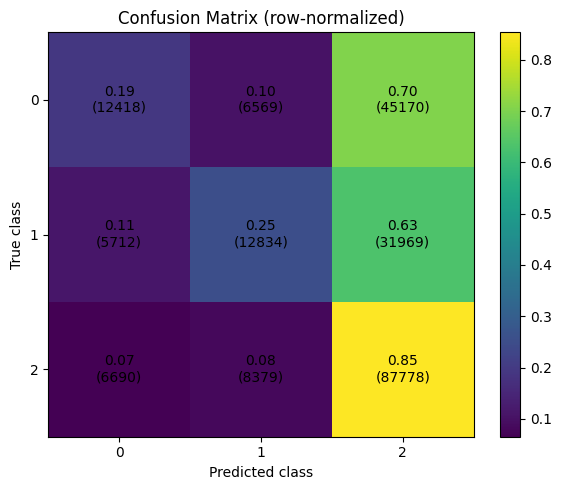

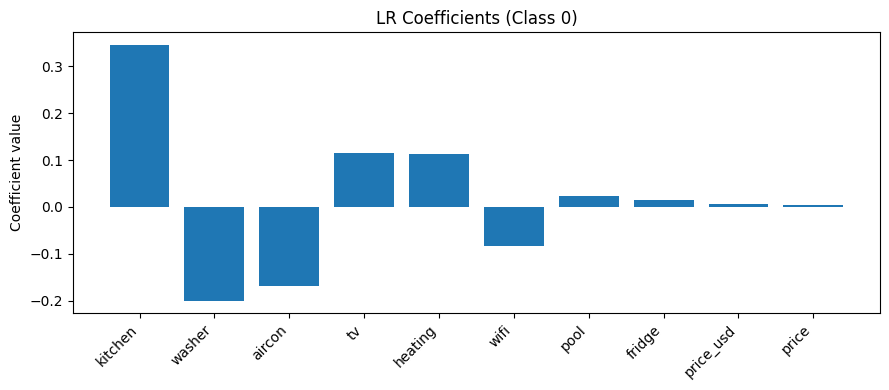

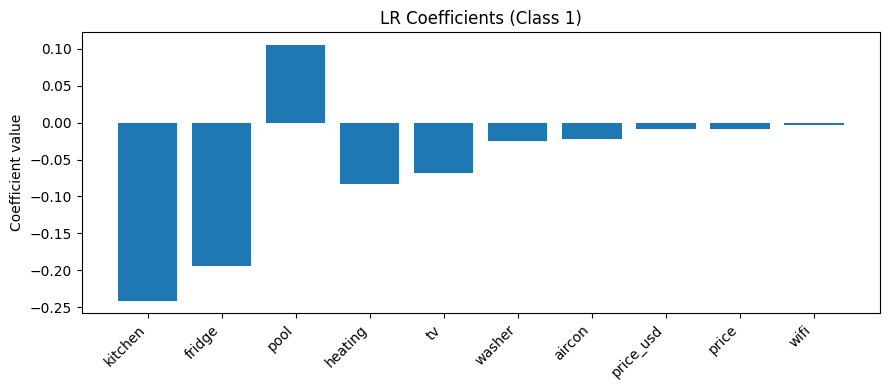

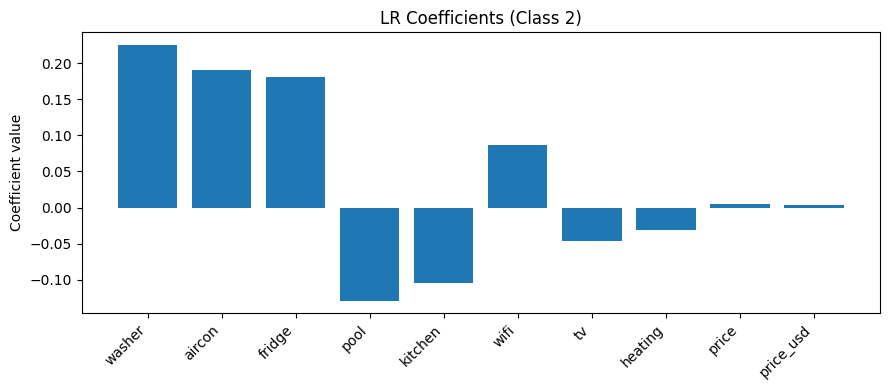

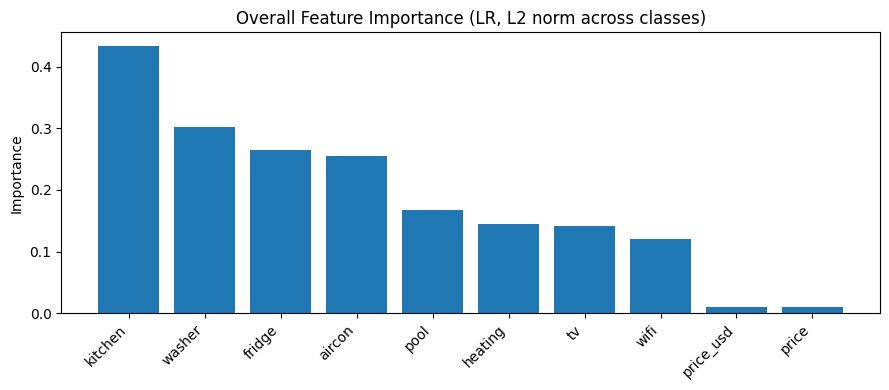


Overall importance ranking (LR):
kitchen: 0.433838
washer: 0.301894
fridge: 0.265306
aircon: 0.255332
pool: 0.167798
heating: 0.144189
tv: 0.141693
wifi: 0.120791
price_usd: 0.011074
price: 0.010909


In [0]:
# Cell 21

# ============================================================
# VISUALIZATIONS for Multinomial LR (TOP10)
# Requires: model_lr, pred_lr, TOP10
# Produces:
# 1) Confusion matrix (counts + row-normalized heatmap)
# 2) Coefficient bar chart per class
# 3) Overall "importance" by L2 norm across classes
# ============================================================

LABEL_COL = "label"  

# -----------------------------
# 1) Confusion matrix: counts + row-normalized heatmap
# -----------------------------
cm_spark = (
    pred_lr
    .groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    )
    .count()
)

cm_pd = cm_spark.toPandas()
classes = [0, 1, 2]

# Dense confusion matrix counts
cm = np.zeros((len(classes), len(classes)), dtype=int)
for _, row in cm_pd.iterrows():
    i = int(row["label"])
    j = int(row["pred"])
    if i in classes and j in classes:
        cm[i, j] = int(row["count"])

print("Confusion matrix (counts):")
print(cm)

# Row-normalized (per-true-class)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, aspect="auto")
plt.title("Confusion Matrix (row-normalized)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(classes, classes)
plt.yticks(classes, classes)
plt.colorbar()

# Add text: normalized + count
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}\n({cm[i, j]})",
            ha="center", va="center"
        )

plt.tight_layout()
plt.show()

# -----------------------------
# 2) Coefficients per class (bar chart)
# -----------------------------
lr_model = model_lr.stages[-1]  # LogisticRegressionModel
coef = lr_model.coefficientMatrix.toArray()  # shape: (numClasses, numFeatures)

feature_names = list(TOP10)

for cls in classes:
    weights = coef[cls]

    # Sort by absolute magnitude for cleaner plot
    order = np.argsort(np.abs(weights))[::-1]
    feats_sorted = [feature_names[i] for i in order]
    w_sorted = [float(weights[i]) for i in order]

    plt.figure(figsize=(9, 4))
    plt.bar(range(len(feats_sorted)), w_sorted)
    plt.title(f"LR Coefficients (Class {cls})")
    plt.xticks(range(len(feats_sorted)), feats_sorted, rotation=45, ha="right")
    plt.ylabel("Coefficient value")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Overall feature importance (L2 norm across classes)
# -----------------------------
overall = np.sqrt((coef ** 2).sum(axis=0))  # length = numFeatures

order = np.argsort(overall)[::-1]
feats_sorted = [feature_names[i] for i in order]
imp_sorted = [float(overall[i]) for i in order]

plt.figure(figsize=(9, 4))
plt.bar(range(len(feats_sorted)), imp_sorted)
plt.title("Overall Feature Importance (LR, L2 norm across classes)")
plt.xticks(range(len(feats_sorted)), feats_sorted, rotation=45, ha="right")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("\nOverall importance ranking (LR):")
for f, s in zip(feats_sorted, imp_sorted):
    print(f"{f}: {s:.6f}")


### Cell 22  OVR + GBT multiclass model
### Train (sampled) → Evaluate (full test) → Feature importance

In [0]:
# Cell 22

# Import missing OneVsRest
from pyspark.ml.classification import OneVsRest

SEED = 42
LABEL_SRC = "ratings_n_score"
LABEL_COL = "label"

# Use TOP10 (or swap to TOP20 if you want)
TOP10 = [
    "washer", "aircon", "kitchen", "fridge",
    "price_usd", "price",
    "heating", "pool", "tv", "wifi"
]

# Speed control: sample ONLY train
TRAIN_SAMPLE_FRAC = 0.30   # 0.10 / 0.30 / 1.0

# ------------------------------------------------
# Helpers
# ------------------------------------------------
def add_3class_label(df):
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None).otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            LABEL_COL,
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col(LABEL_COL).isNotNull())
    )

def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None).otherwise(F.col(c)).cast("double"))
    return out

# ------------------------------------------------
# 1) Label train/test
# ------------------------------------------------
train_l = add_3class_label(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_l  = add_3class_label(test_df ).persist(StorageLevel.MEMORY_AND_DISK)

print("Train rows (valid label):", train_l.count())
print("Test rows  (valid label):", test_l.count())

# ------------------------------------------------
# 2) Sample train only
# ------------------------------------------------
if TRAIN_SAMPLE_FRAC < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

print(f"Train used rows: {train_use.count()} (sample_frac={TRAIN_SAMPLE_FRAC})")
print("Test used rows:", test_l.count(), "(full test)")

# ------------------------------------------------
# 3) Choose features (TOP10 that exist)
# ------------------------------------------------
TOP10 = [c for c in TOP10 if c in train_use.columns]
print("Using features:", TOP10)

# Cast booleans to int
for c, t in train_use.dtypes:
    if t == "boolean" and c in TOP10:
        train_use = train_use.withColumn(c, F.col(c).cast("int"))
        test_l    = test_l.withColumn(c, F.col(c).cast("int"))

# Missing handling
train_use = minus1_to_null(train_use, TOP10)
test_l    = minus1_to_null(test_l,    TOP10)

# ------------------------------------------------
# 4) Pipeline: impute -> assemble -> OneVsRest(GBT)
# ------------------------------------------------
imputer = Imputer(
    inputCols=TOP10,
    outputCols=[f"{c}__imp" for c in TOP10]
).setStrategy("median")

imp_cols = [f"{c}__imp" for c in TOP10]

assembler = VectorAssembler(
    inputCols=imp_cols,
    outputCol="features",
    handleInvalid="keep"
)

# Base binary classifier (runs inside OneVsRest)
gbt = GBTClassifier(
    labelCol=LABEL_COL,
    featuresCol="features",
    maxIter=60,
    maxDepth=5,
    stepSize=0.1,
    subsamplingRate=0.8,
    seed=SEED
)

ovr = OneVsRest(
    classifier=gbt,
    labelCol=LABEL_COL,
    featuresCol="features"
)

pipeline = Pipeline(stages=[imputer, assembler, ovr])

# ------------------------------------------------
# 5) Train
# ------------------------------------------------
model = pipeline.fit(train_use)

# ------------------------------------------------
# 6) Test + metrics
# ------------------------------------------------
pred = model.transform(test_l).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred.count()

eval_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")

f1 = eval_f1.evaluate(pred)
acc = eval_acc.evaluate(pred)

print(f"OneVsRest(GBT) | F1 = {f1:.4f} | Accuracy = {acc:.4f}")

print("Confusion matrix (TEST):")
display(
    pred.groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)

# ------------------------------------------------
# 7) Feature importance (aggregate from the 3 binary GBT models)
# ------------------------------------------------
# ovrModel = last stage of pipeline
ovrModel = model.stages[-1]  # OneVsRestModel
models = ovrModel.models     # list of GBTClassificationModel (one per class)

# Each model has featureImportances over the assembled feature vector
imps = np.array([m.featureImportances.toArray() for m in models])  # shape: (numClasses, numFeatures)
mean_imp = imps.mean(axis=0)

ranked = sorted(zip(TOP10, mean_imp), key=lambda x: x[1], reverse=True)

print("\nMean feature importance across OneVsRest models:")
for f, s in ranked:
    print(f"{f}: {float(s):.6f}")


Train rows (valid label): 4120683
Test rows  (valid label): 217519
Train used rows: 1236353 (sample_frac=0.3)
Test used rows: 217519 (full test)
Using features: ['washer', 'aircon', 'kitchen', 'fridge', 'price_usd', 'price', 'heating', 'pool', 'tv', 'wifi']


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run treasured-frog-410 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/4c72d51dafc04bfa8940966990463ea6
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
OneVsRest(GBT) | F1 = 0.5142 | Accuracy = 0.5567
Confusion matrix (TEST):


label,pred,count
0,0,19232
0,1,4928
0,2,39997
1,0,5315
1,1,12138
1,2,33062
2,0,8273
2,1,4855
2,2,89719



Mean feature importance across OneVsRest models:
kitchen: 0.210079
price: 0.170937
price_usd: 0.125900
washer: 0.125749
aircon: 0.099419
pool: 0.084967
wifi: 0.067718
tv: 0.048194
fridge: 0.038995
heating: 0.028042


### Cell 23  Final model - OVR + GBT (TOP13 + engineered features)
### Feature engineering → label cleaning → train final One-Vs-Rest GBT model

In [0]:
# Cell 23
# ============================================================
# TRAIN: OneVsRest(GBT) with TOP13 (best final model)
# ============================================================

SEED = 42
LABEL_SRC = "ratings_n_score"
LABEL_COL = "label"

# Speed control (set to 1.0 for final report run)
TRAIN_SAMPLE_FRAC = 1.0   # 0.30 for tuning, 1.0 for final

# TOP10 from your V2 RF run
TOP10 = [
    "washer", "aircon", "kitchen", "fridge",
    "price_usd", "price",
    "heating", "pool", "tv", "wifi"
]

# ------------------------------------------------
# Helpers
# ------------------------------------------------
def add_3class_label(df):
    df0 = (
        df
        .withColumn(LABEL_SRC, F.when(F.col(LABEL_SRC) == -1, None)
                               .otherwise(F.col(LABEL_SRC)).cast("double"))
        .filter(F.col(LABEL_SRC).isNotNull())
        .filter((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) <= 10.0))
    )

    return (
        df0.withColumn(
            LABEL_COL,
            F.when((F.col(LABEL_SRC) >= 1.0) & (F.col(LABEL_SRC) < 8.0), F.lit(0.0))
             .when((F.col(LABEL_SRC) >= 8.0) & (F.col(LABEL_SRC) < 9.0), F.lit(1.0))
             .when((F.col(LABEL_SRC) >= 9.0) & (F.col(LABEL_SRC) <= 10.0), F.lit(2.0))
             .otherwise(None)
        ).filter(F.col(LABEL_COL).isNotNull())
    )

def minus1_to_null(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.when(F.col(c) == -1, None)
                                     .otherwise(F.col(c)).cast("double"))
    return out

# ------------------------------------------------
# 1) Feature engineering (cheap + high ROI)
# ------------------------------------------------
amenity_cols = ["washer", "aircon", "kitchen", "fridge", "tv", "wifi", "pool", "heating"]
amenity_cols = [c for c in amenity_cols if c in train_df.columns]

def add_engineered_features(df):
    df = df
    if amenity_cols:
        df = df.withColumn("amenities_sum", sum(F.col(c) for c in amenity_cols))
    else:
        df = df.withColumn("amenities_sum", F.lit(0.0))

    df = (
        df
        .withColumn("log_price_usd", F.log1p(F.col("price_usd")))
        .withColumn("price_per_amenity",
            F.col("price_usd") / (F.col("amenities_sum") + F.lit(1.0))
        )
    )
    return df

train_eng = add_engineered_features(train_df)

TOP13 = TOP10 + ["amenities_sum", "log_price_usd", "price_per_amenity"]

# ------------------------------------------------
# 2) Label + clean
# ------------------------------------------------
train_l = add_3class_label(train_eng).persist(StorageLevel.MEMORY_AND_DISK)
print("Train rows (valid label):", train_l.count())

# ------------------------------------------------
# 3) Sample TRAIN only (optional)
# ------------------------------------------------
if TRAIN_SAMPLE_FRAC < 1.0:
    train_use = train_l.sample(False, TRAIN_SAMPLE_FRAC, SEED).persist(StorageLevel.MEMORY_AND_DISK)
else:
    train_use = train_l

print(f"Train used rows: {train_use.count()} (sample_frac={TRAIN_SAMPLE_FRAC})")

# ------------------------------------------------
# 4) Keep only features that exist
# ------------------------------------------------
TOP13 = [c for c in TOP13 if c in train_use.columns]
print("Using features:", TOP13)

# Cast booleans to int
for c, t in train_use.dtypes:
    if t == "boolean" and c in TOP13:
        train_use = train_use.withColumn(c, F.col(c).cast("int"))

# Missing handling
train_use = minus1_to_null(train_use, TOP13)

# ------------------------------------------------
# 5) Pipeline: impute -> assemble -> OneVsRest(GBT)
# ------------------------------------------------
imputer = Imputer(
    inputCols=TOP13,
    outputCols=[f"{c}__imp" for c in TOP13]
).setStrategy("median")

imp_cols = [f"{c}__imp" for c in TOP13]

assembler = VectorAssembler(
    inputCols=imp_cols,
    outputCol="features",
    handleInvalid="keep"
)

gbt = GBTClassifier(
    labelCol=LABEL_COL,
    featuresCol="features",
    maxIter=80,
    maxDepth=5,
    stepSize=0.1,
    subsamplingRate=0.8,
    seed=SEED
)

ovr = OneVsRest(
    classifier=gbt,
    labelCol=LABEL_COL,
    featuresCol="features"
)

pipeline = Pipeline(stages=[imputer, assembler, ovr])

# ------------------------------------------------
# 6) Train
# ------------------------------------------------
model_final = pipeline.fit(train_use)

print("Training finished.")


Train rows (valid label): 4120683
Train used rows: 4120683 (sample_frac=1.0)
Using features: ['washer', 'aircon', 'kitchen', 'fridge', 'price_usd', 'price', 'heating', 'pool', 'tv', 'wifi', 'amenities_sum', 'log_price_usd', 'price_per_amenity']


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run suave-snipe-616 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850/runs/0279253a3fee4ddba356bf1beb82c2f6
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/1072358835251850
Training finished.


### Cell 24  Final evaluation - OVR + GBT (TOP13)
### Apply same feature engineering to test → predict → report Accuracy & Macro-F1 → confusion matrix

In [0]:
# Cell 24
# ============================================================
# TEST: Evaluate final OneVsRest(GBT) model
# ============================================================

# ------------------------------------------------
# 1) Apply same feature engineering to TEST
# ------------------------------------------------
test_eng = add_engineered_features(test_df)

test_l = add_3class_label(test_eng).persist(StorageLevel.MEMORY_AND_DISK)
print("Test rows (valid label):", test_l.count())

# Cast booleans to int
for c, t in test_l.dtypes:
    if t == "boolean" and c in TOP13:
        test_l = test_l.withColumn(c, F.col(c).cast("int"))

# Missing handling
test_l = minus1_to_null(test_l, TOP13)

# ------------------------------------------------
# 2) Predict
# ------------------------------------------------
pred_final = model_final.transform(test_l).persist(StorageLevel.MEMORY_AND_DISK)
_ = pred_final.count()

# ------------------------------------------------
# 3) Metrics
# ------------------------------------------------
eval_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")

f1_final = eval_f1.evaluate(pred_final)
acc_final = eval_acc.evaluate(pred_final)

print(f"FINAL MODEL — OneVsRest(GBT + TOP13)")
print(f"Accuracy = {acc_final:.4f}")
print(f"Macro F1 = {f1_final:.4f}")

print("Confusion matrix (TEST):")
display(
    pred_final.groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    ).count().orderBy("label", "pred")
)


Test rows (valid label): 217519
FINAL MODEL — OneVsRest(GBT + TOP13)
Accuracy = 0.5602
Macro F1 = 0.5198
Confusion matrix (TEST):


label,pred,count
0,0,19814
0,1,4898
0,2,39445
1,0,5645
1,1,12595
1,2,32275
2,0,8372
2,1,5022
2,2,89453


### Cell 25  Final diagnostics - confusion matrix (counts + normalized heatmap)  mean OVR-GBT feature importance  bar plot

Confusion matrix (counts):
[[19814  4898 39445]
 [ 5645 12595 32275]
 [ 8372  5022 89453]]


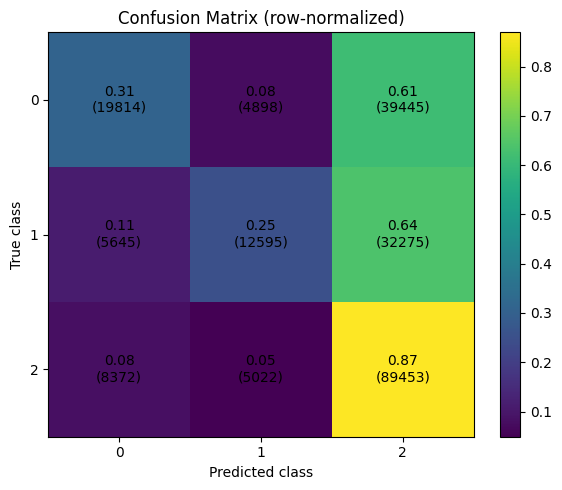


Mean feature importance across OneVsRest models:
kitchen: 0.181594
price_per_amenity: 0.141509
price: 0.139527
amenities_sum: 0.133284
price_usd: 0.113883
washer: 0.069598
aircon: 0.066767
pool: 0.041461
wifi: 0.035441
tv: 0.029915
fridge: 0.027576
heating: 0.010311
log_price_usd: 0.009134


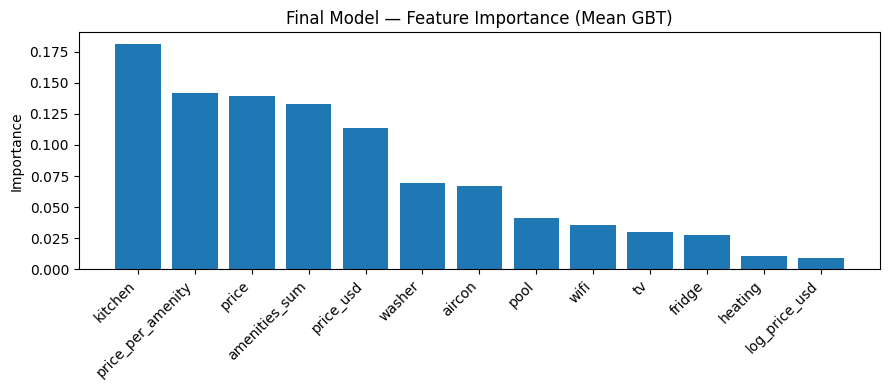

In [0]:
# Cell 25
# ============================================================
# Visualizations + Feature Importance (Final Model)
# ============================================================

LABEL_COL = "label"

# -----------------------------
# 1) Confusion matrix heatmap
# -----------------------------
cm_spark = (
    pred_final
    .groupBy(
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("pred")
    )
    .count()
)

cm_pd = cm_spark.toPandas()
classes = [0, 1, 2]

cm = np.zeros((len(classes), len(classes)), dtype=int)
for _, row in cm_pd.iterrows():
    i = int(row["label"])
    j = int(row["pred"])
    if i in classes and j in classes:
        cm[i, j] = int(row["count"])

print("Confusion matrix (counts):")
print(cm)

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, aspect="auto")
plt.title("Confusion Matrix (row-normalized)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(classes, classes)
plt.yticks(classes, classes)
plt.colorbar()

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i, j]})",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

# -----------------------------
# 2) Feature importance (mean across OneVsRest models)
# -----------------------------
ovr_model = model_final.stages[-1]
models = ovr_model.models

imps = np.array([m.featureImportances.toArray() for m in models])
mean_imp = imps.mean(axis=0)

ranked = sorted(zip(TOP13, mean_imp), key=lambda x: x[1], reverse=True)

print("\nMean feature importance across OneVsRest models:")
for f, s in ranked:
    print(f"{f}: {float(s):.6f}")

# Bar plot
feats, scores = zip(*ranked)

plt.figure(figsize=(9, 4))
plt.bar(range(len(feats)), scores)
plt.title("Final Model — Feature Importance (Mean GBT)")
plt.xticks(range(len(feats)), feats, rotation=45, ha="right")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
